  <img src="https://raw.githubusercontent.com/scalabrinig/cdProjetoAplicadoIV/d093146488f56dfcf0ef286bcee8efe0e71b9c76/figuras/mackenzie_logo.jpg" width="25%" align="right"/>

# **PROJETO APLICADO IV - Ciência de Dados EaD - 2026/01**


# **Entrega 4**

---

# **Titulo do Projeto**:

**Previsão de Demanda de Energia Elétrica com Base em Séries Temporais: Uma Abordagem com Pipeline de Dados e Modelos Preditivos**

In [ ]:
#@title **Identificação do Grupo e Opção do Projeto**

#@markdown Integrantes do Grupo, nome completo em ordem alfabética (*informe: \<nome\>, \<matrícula\>*)
Aluno1 = 'BRUNA FREITAS SOARES, 10441222 ' #@param {type:"string"}
Aluno2 = 'HEVERTON VALERIO DE LIMA, 10348034' #@param {type:"string"}
Aluno3 = 'DIOGO MOREIRA POLTOSI REZENDE, 10433404' #@param {type:"string"}
Aluno4 = 'JOÃO VICTOR FONTEBASSO ALVES, 10441047' #@param {type:"string"}

# **Resumo**

Este trabalho apresenta o desenvolvimento de um produto analítico baseado em séries temporais para prever a carga mensal de energia elétrica no Sistema Interligado Nacional (SIN), utilizando dados públicos do Operador Nacional do Sistema Elétrico (ONS, 2026). A série histórica de Carga de Energia Mensal (Jan/2000 a Jan/2026), totalizando 313 observações mensais por subsistema, foi submetida a um pipeline completo de preparação, análise exploratória — incluindo decomposição sazonal, testes de estacionariedade (ADF/KPSS) e análise de autocorrelação — e modelagem preditiva. Foram implementados e comparados três modelos: SARIMA (com seleção automática de parâmetros via `auto_arima`), Holt-Winters Multiplicativo e XGBoost com engenharia de atributos temporais. A avaliação por métricas MAE, RMSE e MAPE, complementada por validação cruzada temporal, demonstrou que o modelo SARIMA obteve o melhor desempenho preditivo, sendo utilizado para gerar projeções de 12 meses futuros (Fev/2026 a Jan/2027). O projeto contribui para o Objetivo de Desenvolvimento Sustentável 12 — Produção e Consumo Sustentáveis (ONU, 2026) — ao fornecer uma ferramenta analítica replicável que apoia o planejamento energético e o uso racional dos recursos.

# **Introdução**

O setor elétrico brasileiro é um dos maiores e mais complexos do mundo, com uma capacidade instalada de geração que ultrapassou 200 GW em 2024, atendendo a mais de 90 milhões de unidades consumidoras em todo o território nacional (ONS, 2026). O Sistema Interligado Nacional (SIN) é responsável por coordenar a geração e a transmissão de energia elétrica em praticamente todo o país, conectando as regiões Sul, Sudeste/Centro-Oeste, Nordeste e parte da região Norte por meio de uma extensa rede de linhas de transmissão. Segundo a Empresa de Pesquisa Energética (EPE, 2024), o consumo total de energia elétrica no Brasil atingiu cerca de 513 TWh em 2023, representando um crescimento de aproximadamente 5% em relação ao ano anterior.

Nesse contexto, a previsão de demanda de energia elétrica assume papel estratégico no planejamento e na operação do sistema elétrico. A capacidade de antecipar as variações de carga permite otimizar o despacho de usinas, reduzir custos operacionais e minimizar riscos de desabastecimento (OLIVEIRA; ABARRACIN; SILVA, 2024). A modelagem de séries temporais constitui uma das principais ferramentas analíticas para essa finalidade, permitindo a identificação de padrões sazonais, tendências de longo prazo e componentes cíclicos que caracterizam o comportamento do consumo energético ao longo do tempo.

Como Projeto Aplicado IV, será elaborado um modelo de séries temporais para a previsão do consumo de energia elétrica no contexto do SIN, com foco em apoiar o uso mais eficiente e responsável desse recurso. O estudo visa criar uma solução capaz de analisar padrões, tendências e sazonalidades presentes na série histórica de carga de energia elétrica, fornecendo projeções sobre o uso futuro de energia a partir de dados reais divulgados pelo Operador Nacional do Sistema Elétrico (ONS, 2026).

## **Motivações e justificativa**

### Motivação

Em um cenário de crescente pressão sobre os recursos naturais, a transição para modelos energéticos inteligentes não é apenas uma escolha técnica, mas uma necessidade ética. A motivação central deste estudo reside no fato de que compreender o comportamento do consumo energético e antecipar suas variações é uma necessidade estratégica para o planejamento do setor elétrico brasileiro. Segundo Oliveira, Abarracin e Silva (2024), a análise de séries temporais aplicada a dados de consumo de energia permite identificar padrões, tendências e sazonalidades, contribuindo para uma visão mais precisa e orientada por dados.

Além disso, a disponibilidade de dados públicos fornecidos por instituições oficiais, como o Operador Nacional do Sistema Elétrico (ONS, 2026), possibilita o desenvolvimento de soluções analíticas baseadas em dados reais, promovendo maior aderência entre o projeto acadêmico e problemas do mundo real. Conforme destacado por Oliveira (2026a), repositórios abertos de dados de séries temporais oferecem oportunidades valiosas para a aplicação prática de técnicas de modelagem preditiva.

### Justificativa

#### Contribuição técnica

Do ponto de vista técnico, este projeto contribui para a área de ciência de dados e séries temporais ao propor a construção de um pipeline analítico completo — desde a coleta e preparação dos dados até a modelagem preditiva — aplicado a um problema real do setor energético. A comparação entre diferentes modelos de previsão (como SARIMA, suavização exponencial e abordagens baseadas em machine learning) permite avaliar suas capacidades e limitações em cenários reais de previsão de carga (PEJUCA, 2026). Adicionalmente, a documentação detalhada do processo exploratório e da engenharia de atributos contribui como referência metodológica para trabalhos futuros na área de previsão de demanda energética.

#### Contribuição social

A contribuição social deste projeto está diretamente relacionada ao Objetivo de Desenvolvimento Sustentável (ODS) 12 da ONU — Produção e Consumo Sustentáveis (ONU, 2026). A previsão acurada da demanda de energia elétrica permite: (i) o uso mais racional dos recursos energéticos, evitando desperdícios na geração; (ii) a redução do acionamento desnecessário de usinas térmicas, que possuem maior impacto ambiental; e (iii) o fornecimento de informações que possam orientar políticas públicas e conscientizar a sociedade sobre padrões de consumo. Dessa forma, os resultados deste projeto possuem potencial para apoiar decisões que promovam um sistema energético mais eficiente e sustentável.

## **Objetivo**

**Objetivo geral:** Desenvolver um produto analítico baseado em séries temporais para prever a carga mensal de energia elétrica no Sistema Interligado Nacional (SIN), utilizando dados públicos do ONS (2026), de forma a apoiar o planejamento e o consumo responsável de energia elétrica no Brasil, em conformidade com o ODS 12 (ONU, 2026).

**Objetivos específicos:**

1. Analisar o comportamento histórico da carga mensal de energia elétrica no SIN, identificando tendências, sazonalidade e variações relevantes na série temporal.
2. Construir um pipeline de processamento de dados que contemple coleta, limpeza, transformação, visualização e preparação dos dados para modelagem, conforme metodologia proposta por Oliveira, Abarracin e Silva (2024).
3. Selecionar e implementar diferentes técnicas de modelagem de séries temporais (por exemplo, modelos SARIMA, suavização exponencial ou modelos com componentes de tendência e sazonalidade) para previsão da carga.
4. Avaliar e comparar o desempenho dos modelos por meio de métricas adequadas (como MAE, RMSE ou MAPE), selecionando aquele com melhor desempenho para o problema proposto.

Temos como objetivo extensionista implementar um sistema em conformidade com o Objetivo de Desenvolvimento Sustentável (ODS) 12: Produção e Consumo Sustentáveis (ONU, 2026).

## **Descrição da base de dados**

A base de dados utilizada neste projeto é obtida do portal de dados abertos do Operador Nacional do Sistema Elétrico (ONS, 2026), disponível em https://dados.ons.org.br. O conjunto de dados selecionado é o **"Carga de Energia Mensal"**, que contém registros históricos da carga de energia elétrica por subsistema do SIN em base mensal, medida em MWmed (megawatts médios).

### Formato e dimensões da base

O arquivo está disponível em formato CSV (delimitado por ponto e vírgula, codificação UTF-8) e apresenta a seguinte estrutura:

- **Shape (dimensões):** 1.253 registros × 4 colunas (excluindo o cabeçalho)
- **Período temporal:** janeiro de 2000 a janeiro de 2026 (mais de 26 anos de dados históricos)
- **Granularidade:** mensal, com uma observação por subsistema por mês

### Descrição das colunas

| Coluna | Tipo | Descrição |
|--------|------|-----------|
| `id_subsistema` | Texto (categórica) | Código identificador do subsistema elétrico (N, NE, S, SE) |
| `nom_subsistema` | Texto (categórica) | Nome completo do subsistema: Norte, Nordeste, Sul, Sudeste/Centro-Oeste |
| `din_instante` | Data (YYYY-MM-DD) | Data de referência do registro mensal (último dia do mês) |
| `val_cargaenergiamwmed` | Numérica (float) | Valor da carga de energia elétrica no mês, medida em MWmed |

### Observações sobre os dados

Conforme documentação do ONS (2026), os dados possuem características distintas em diferentes períodos:
- **Até dezembro/2014:** representam a carga atendida por usinas despachadas e/ou programadas pelo ONS, com base em dados do Sistema de Supervisão e Controle.
- **De janeiro/2015 a fevereiro/2021:** incluem também usinas não despachadas pelo ONS, com dados verificados provenientes do Sistema de Medição para Faturamento (CCEE).
- **A partir de abril/2023:** passou a ser incorporado o valor estimado da micro e minigeração distribuída (MMGD), com base em dados meteorológicos verificados.

Os dados fazem parte de um processo de consistência recorrente e podem ser atualizados após sua publicação.

# **Referencial Teórico**

## Séries temporais e previsão de demanda energética

Uma série temporal é uma sequência de observações ordenadas no tempo, cujo comportamento pode ser descrito por componentes de **tendência**, **sazonalidade**, **ciclos** e **ruído** (OLIVEIRA; ABARRACIN; SILVA, 2024). No contexto energético, a previsão de demanda é essencial para o planejamento da operação do sistema elétrico, permitindo otimizar o despacho de geração e reduzir custos e riscos de desabastecimento.

## Modelos estatísticos clássicos

Os modelos da família ARIMA (AutoRegressive Integrated Moving Average) e suas extensões sazonais (SARIMA) constituem a abordagem clássica para modelagem de séries temporais univariadas. O modelo SARIMA incorpora componentes autorregressivos e de médias móveis tanto na parte regular quanto na sazonal, sendo amplamente utilizado para séries com periodicidade definida (HYNDMAN; ATHANASOPOULOS, 2021). A suavização exponencial tripla (Holt-Winters) oferece uma alternativa que modela explicitamente nível, tendência e sazonalidade, sendo eficaz quando esses componentes são bem definidos (OLIVEIRA; ABARRACIN; SILVA, 2024).

## Modelos de Machine Learning para séries temporais

Abordagens baseadas em Gradient Boosting, como o XGBoost (CHEN; GUESTRIN, 2016), têm demonstrado desempenho competitivo em problemas de previsão temporal, especialmente quando combinadas com engenharia de atributos que transforma a série em um problema de regressão supervisionada. A criação de features como lags, médias móveis e indicadores sazonais permite que algoritmos de árvore capturem padrões não-lineares e interações complexas entre variáveis temporais (PEJUCA, 2026).

## Trabalhos correlatos

Oliveira (2026b; 2026c) apresenta aplicações práticas de modelos de séries temporais em dados de varejo, demonstrando pipelines completos desde a preparação dos dados até a avaliação preditiva. Pejuca (2026) propõe a combinação de ARIMA e XGBoost para previsão de séries temporais, explorando as complementaridades entre modelos estatísticos e de machine learning. Smith et al. (2017) disponibilizam a biblioteca `pmdarima`, que automatiza a seleção de parâmetros ARIMA, facilitando a identificação de modelos adequados. Estas referências fundamentaram a escolha metodológica deste projeto, que combina abordagens estatísticas clássicas com machine learning para uma avaliação comparativa robusta.

# **Diagrama de Solução**

O diagrama abaixo apresenta a arquitetura final do pipeline analítico desenvolvido neste projeto:

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                    PIPELINE DE PREVISÃO DE CARGA DO SIN                      │
└─────────────────────────────────────────────────────────────────────────────┘

┌──────────────┐    ┌──────────────────┐    ┌──────────────────────────────┐
│  COLETA DE   │    │  PRÉ-PROCESSAM.  │    │   ANÁLISE EXPLORATÓRIA       │
│    DADOS     │───▶│  E PREPARAÇÃO    │───▶│         (EDA)                │
│              │    │                  │    │                              │
│ ONS Dados    │    │ • Limpeza        │    │ • Visualização temporal      │
│ Abertos      │    │ • Conversão tipos│    │ • Decomposição (adit./mult.) │
│ (CSV mensal) │    │ • Verificação    │    │ • Testes ADF/KPSS            │
│              │    │   gaps e outliers │    │ • ACF/PACF                   │
│              │    │ • Agregação SIN  │    │ • Diferenciação              │
└──────────────┘    └──────────────────┘    └──────────────────────────────┘
                                                          │
                    ┌─────────────────────────────────────┘
                    ▼
┌──────────────────────────────────────────────────────────────────────────────┐
│                           MODELAGEM PREDITIVA                                │
├──────────────────────┬──────────────────────┬────────────────────────────────┤
│   SARIMA             │   Holt-Winters       │   XGBoost                      │
│   (Box-Jenkins)      │   Multiplicativo     │   (Machine Learning)           │
│                      │                      │                                │
│ • auto_arima         │ • Tendência mult.    │ • Feature engineering          │
│ • Diagnóstico resíd. │ • Sazonalidade mult. │   (lags, médias móveis,        │
│ • Validação cruzada  │                      │    indicadores sazonais)       │
│   temporal           │                      │ • GridSearchCV + TimeSeriesSplit│
└──────────────────────┴──────────────────────┴────────────────────────────────┘
                                    │
                                    ▼
┌──────────────────────────────────────────────────────────────────────────────┐
│                    AVALIAÇÃO E COMPARAÇÃO                                     │
│                                                                              │
│  • Métricas: MAE, RMSE, MAPE       • Seleção do melhor modelo               │
│  • Comparação visual (teste)        • Previsão futura (12 meses)             │
└──────────────────────────────────────────────────────────────────────────────┘
```

**Descrição do pipeline:**

1. **Coleta:** Dados de Carga de Energia Mensal obtidos do portal ONS Dados Abertos em formato CSV.
2. **Pré-processamento:** Limpeza, verificação de integridade temporal, tratamento de tipos e agregação dos 4 subsistemas em série única do SIN.
3. **EDA:** Análise visual, decomposição sazonal, testes de estacionariedade e identificação da estrutura de autocorrelação para orientar a modelagem.
4. **Modelagem:** Três abordagens complementares — SARIMA (estatístico clássico), Holt-Winters (suavização exponencial) e XGBoost (machine learning) — treinadas com divisão temporal 80/20.
5. **Avaliação:** Comparação por métricas padronizadas e validação cruzada temporal, com seleção do modelo final para previsão futura.

# **Referências**

CHEN, T.; GUESTRIN, C. XGBoost: A Scalable Tree Boosting System. In: **Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining**. San Francisco: ACM, 2016. p. 785–794. DOI: 10.1145/2939672.2939785.

EPE – EMPRESA DE PESQUISA ENERGÉTICA. **Anuário Estatístico de Energia Elétrica 2024**. Rio de Janeiro: EPE, 2024. Disponível em: https://www.epe.gov.br/pt/publicacoes-dados-abertos/publicacoes/anuario-estatistico-de-energia-eletrica. Acesso em: 01 mar. 2026.

HYNDMAN, R. J.; ATHANASOPOULOS, G. **Forecasting: Principles and Practice**. 3. ed. Melbourne: OTexts, 2021. Disponível em: https://otexts.com/fpp3/. Acesso em: 16 abr. 2026.

OLIVEIRA, R.; ABARRACIN, O. Y. E.; SILVA, G. R. **Introdução às séries temporais: uma abordagem prática em Python**. São Paulo: Editora Mackenzie, 2024.

OLIVEIRA, R. **Introdução às Séries Temporais: Uma Abordagem Prática em Python – Material complementar** (GitHub). Repositório Temporal. Disponível em: https://github.com/Rogerio-mack/Temporal. Acesso em: 01 mar. 2026a.

OLIVEIRA, R. **Time Series – Varejo** (GitHub). Repositório time_series_varejo. Disponível em: https://github.com/Rogerio-mack/time_series_varejo. Acesso em: 01 mar. 2026b.

OLIVEIRA, R. **Séries Temporais – Varejo 2** (GitHub). Repositório SeriesTemporais-Varejo2. Disponível em: https://github.com/Rogerio-mack/SeriesTemporais-Varejo2. Acesso em: 01 mar. 2026c.

ONS – OPERADOR NACIONAL DO SISTEMA ELÉTRICO. **ONS Dados Abertos – Carga de Energia Mensal**. Disponível em: https://dados.ons.org.br/dataset/carga-mensal. Acesso em: 25 mar. 2026.

ONU – ORGANIZAÇÃO DAS NAÇÕES UNIDAS. **Objetivos de Desenvolvimento Sustentável – ODS 12: Consumo e Produção Responsáveis**. Disponível em: https://www.un.org/sustainabledevelopment/sustainable-consumption-production. Acesso em: 01 mar. 2026.

PEJUCA. **Time Series – ARIMA & XGBoost** (GitHub). Repositório Time-Series---ARIMA-XGBoost. Disponível em: https://github.com/Pejuca/Time-Series---ARIMA-XGBoost. Acesso em: 01 mar. 2026.

SMITH, T. J. et al. **pmdarima: ARIMA estimators for Python**. 2017. Disponível em: https://alkaline-ml.com/pmdarima/. Acesso em: 16 abr. 2026.

---

# **Entrega 2 — Análise de Séries Temporais**

---

# **1. Preparação e Adequação da Base de Dados**

Nesta seção, realizamos a importação, inspeção, limpeza e transformação da base de dados de Carga de Energia Mensal do ONS (2026). O objetivo é preparar os dados para a análise exploratória de séries temporais, justificando cada etapa do processo.

## 1.1 Importação das bibliotecas

Importamos as bibliotecas necessárias para manipulação de dados, visualização e análise de séries temporais.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
plt.style.use('seaborn-v0_8-whitegrid')

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


## 1.2 Carregamento e inspeção inicial dos dados

Carregamos o arquivo CSV da base de Carga de Energia Mensal e realizamos uma inspeção preliminar para compreender a estrutura, tipos de dados e possíveis inconsistências.

In [ ]:
df = pd.read_csv('/content/CARGA_MENSAL.csv', sep=';')

print("=" * 60)
print("INSPEÇÃO INICIAL DA BASE DE DADOS")
print("=" * 60)

print(f"\nShape (dimensões): {df.shape[0]} linhas × {df.shape[1]} colunas")
print(f"\nColunas: {list(df.columns)}")

print("\n--- Primeiros 10 registros ---")
display(df.head(10))

print("\n--- Últimos 5 registros ---")
display(df.tail(5))

print("\n--- Informações sobre tipos e valores nulos ---")
df.info()

print("\n--- Estatísticas descritivas ---")
display(df.describe(include='all'))

INSPEÇÃO INICIAL DA BASE DE DADOS

Shape (dimensões): 1252 linhas × 4 colunas

Colunas: ['id_subsistema', 'nom_subsistema', 'din_instante', 'val_cargaenergiamwmed']

--- Primeiros 10 registros ---


,id_subsistema,nom_subsistema,din_instante,val_cargaenergiamwmed
0,N,Norte,2000-01-31,2397.644086
1,NE,Nordeste,2000-01-31,5666.025269
2,S,Sul,2000-01-31,6726.535148
3,SE,Sudeste/Centro-Oeste,2000-01-31,24463.186156
4,N,Norte,2000-02-29,2409.035489
5,NE,Nordeste,2000-02-29,5780.173563
6,S,Sul,2000-02-29,6887.400287
7,SE,Sudeste/Centro-Oeste,2000-02-29,25588.788506
8,N,Norte,2000-03-31,2407.972849
9,NE,Nordeste,2000-03-31,5839.950538



--- Últimos 5 registros ---


,id_subsistema,nom_subsistema,din_instante,val_cargaenergiamwmed
1247,SE,Sudeste/Centro-Oeste,2025-12-31,46611.914989
1248,N,Norte,2026-01-31,8155.308135
1249,NE,Nordeste,2026-01-31,14016.399397
1250,S,Sul,2026-01-31,14900.068028
1251,SE,Sudeste/Centro-Oeste,2026-01-31,46819.314421



--- Informações sobre tipos e valores nulos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1252 entries, 0 to 1251
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_subsistema          1252 non-null   object 
 1   nom_subsistema         1252 non-null   object 
 2   din_instante           1252 non-null   object 
 3   val_cargaenergiamwmed  1252 non-null   float64
dtypes: float64(1), object(3)
memory usage: 39.3+ KB

--- Estatísticas descritivas ---


,id_subsistema,nom_subsistema,din_instante,val_cargaenergiamwmed
count,1252,1252,1252,1252.000000
unique,4,4,313,NaN
top,N,Norte,2026-01-31,NaN
freq,313,313,4,NaN
mean,NaN,NaN,NaN,14525.690372
std,NaN,NaN,NaN,12316.944268
min,NaN,NaN,NaN,2027.057661
25%,NaN,NaN,NaN,6178.128511
50%,NaN,NaN,NaN,9586.378373
75%,NaN,NaN,NaN,17575.622855


## 1.3 Limpeza e tratamento dos dados

Verificamos a existência de valores nulos, registros duplicados e realizamos as conversões de tipo necessárias. A coluna de data é convertida para o tipo `datetime` do pandas para possibilitar a manipulação temporal adequada.

**Justificativa:** A conversão da coluna `din_instante` para datetime é essencial para que o pandas reconheça a série como temporal, permitindo indexação por datas, reamostragem e visualizações com eixo temporal adequado.

In [ ]:
print("=" * 60)
print("LIMPEZA E TRATAMENTO DOS DADOS")
print("=" * 60)

# Verificar valores nulos
print("\n--- Valores nulos por coluna ---")
print(df.isnull().sum())

# Verificar duplicados
duplicados = df.duplicated().sum()
print(f"\n--- Registros duplicados: {duplicados} ---")

# Converter coluna de data para datetime
df['din_instante'] = pd.to_datetime(df['din_instante'])

# Verificar tipos após conversão
print("\n--- Tipos de dados após conversão ---")
print(df.dtypes)

# Verificar valores únicos das colunas categóricas
print("\n--- Subsistemas presentes na base ---")
print(df[['id_subsistema', 'nom_subsistema']].drop_duplicates())

# Verificar período temporal
print(f"\n--- Período: {df['din_instante'].min().strftime('%m/%Y')} a {df['din_instante'].max().strftime('%m/%Y')} ---")
print(f"--- Total de meses distintos: {df['din_instante'].nunique()} ---")

LIMPEZA E TRATAMENTO DOS DADOS

--- Valores nulos por coluna ---
id_subsistema            0
nom_subsistema           0
din_instante             0
val_cargaenergiamwmed    0
dtype: int64

--- Registros duplicados: 0 ---

--- Tipos de dados após conversão ---
id_subsistema                    object
nom_subsistema                   object
din_instante             datetime64[ns]
val_cargaenergiamwmed           float64
dtype: object

--- Subsistemas presentes na base ---
  id_subsistema        nom_subsistema
0             N                 Norte
1            NE              Nordeste
2             S                   Sul
3            SE  Sudeste/Centro-Oeste

--- Período: 01/2000 a 01/2026 ---
--- Total de meses distintos: 313 ---


## 1.4 Verificação de gaps temporais

Para garantir a integridade da série temporal, verificamos se existem meses faltantes na base. Uma série com lacunas temporais pode comprometer decomposições, testes de estacionariedade e a modelagem posterior. A verificação é feita comparando as datas esperadas (sequência mensal completa) com as datas presentes nos dados, para cada subsistema.

In [ ]:
print("=" * 60)
print("VERIFICAÇÃO DE GAPS TEMPORAIS")
print("=" * 60)

# Gerar sequência completa de meses esperados
data_min = df['din_instante'].min()
data_max = df['din_instante'].max()
meses_esperados = pd.date_range(start=data_min, end=data_max, freq='ME')

print(f"\nPeríodo: {data_min.strftime('%m/%Y')} a {data_max.strftime('%m/%Y')}")
print(f"Total de meses esperados: {len(meses_esperados)}")
print(f"Total de meses presentes: {df['din_instante'].nunique()}")

# Verificar gaps por subsistema
print("\n--- Gaps por subsistema ---")
gaps_encontrados = False
for sub in df['id_subsistema'].unique():
    datas_sub = df[df['id_subsistema'] == sub]['din_instante'].sort_values()
    meses_faltantes = set(meses_esperados) - set(datas_sub)
    if len(meses_faltantes) > 0:
        gaps_encontrados = True
        print(f"\n  ⚠ {sub}: {len(meses_faltantes)} mês(es) faltante(s):")
        for m in sorted(meses_faltantes):
            print(f"    - {m.strftime('%m/%Y')}")
    else:
        print(f"  ✔ {sub}: série completa ({len(datas_sub)} meses)")

if not gaps_encontrados:
    print("\n✔ Nenhum gap temporal encontrado. A série está completa para todos os subsistemas.")

VERIFICAÇÃO DE GAPS TEMPORAIS

Período: 01/2000 a 01/2026
Total de meses esperados: 313
Total de meses presentes: 313

--- Gaps por subsistema ---
  ✔ N: série completa (313 meses)
  ✔ NE: série completa (313 meses)
  ✔ S: série completa (313 meses)
  ✔ SE: série completa (313 meses)

✔ Nenhum gap temporal encontrado. A série está completa para todos os subsistemas.


## 1.5 Detecção e tratamento de outliers

Outliers (valores discrepantes) podem distorcer análises estatísticas e comprometer o desempenho de modelos preditivos. Realizamos a detecção de outliers utilizando dois métodos complementares:

- **Método IQR (Intervalo Interquartil):** Valores abaixo de Q1 − 1,5 × IQR ou acima de Q3 + 1,5 × IQR são considerados outliers.
- **Z-Score:** Valores com |Z| > 3 (mais de 3 desvios padrão da média) são considerados outliers.

A análise é feita tanto na base bruta (por subsistema) quanto na série agregada do SIN, para que a decisão de tratamento seja documentada e justificada.

In [ ]:
print("=" * 60)
print("DETECÇÃO DE OUTLIERS — POR SUBSISTEMA (Método IQR)")
print("=" * 60)

outliers_total = 0

for sub in df['id_subsistema'].unique():
    dados_sub = df[df['id_subsistema'] == sub]['val_cargaenergiamwmed']
    Q1 = dados_sub.quantile(0.25)
    Q3 = dados_sub.quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    outliers = dados_sub[(dados_sub < limite_inf) | (dados_sub > limite_sup)]
    outliers_total += len(outliers)

    nome_sub = df[df['id_subsistema'] == sub]['nom_subsistema'].iloc[0]
    print(f"\n  {nome_sub} ({sub}):")
    print(f"    Q1={Q1:,.2f} | Q3={Q3:,.2f} | IQR={IQR:,.2f}")
    print(f"    Limites: [{limite_inf:,.2f}, {limite_sup:,.2f}]")
    print(f"    Outliers encontrados: {len(outliers)}")
    if len(outliers) > 0:
        idx_outliers = df[(df['id_subsistema'] == sub) &
                         ((df['val_cargaenergiamwmed'] < limite_inf) |
                          (df['val_cargaenergiamwmed'] > limite_sup))]
        for _, row in idx_outliers.iterrows():
            print(f"      ⚠ {row['din_instante'].strftime('%m/%Y')}: {row['val_cargaenergiamwmed']:,.2f} MWmed")

print(f"\n--- Total de outliers (IQR) em todos os subsistemas: {outliers_total} ---")

DETECÇÃO DE OUTLIERS — POR SUBSISTEMA (Método IQR)

  Norte (N):
    Q1=3,351.24 | Q3=5,619.42 | IQR=2,268.17
    Limites: [-51.02, 9,021.68]
    Outliers encontrados: 0

  Nordeste (NE):
    Q1=6,968.13 | Q3=10,930.42 | IQR=3,962.29
    Limites: [1,024.69, 16,873.85]
    Outliers encontrados: 0

  Sul (S):
    Q1=7,838.01 | Q3=11,690.98 | IQR=3,852.97
    Limites: [2,058.57, 17,470.43]
    Outliers encontrados: 0

  Sudeste/Centro-Oeste (SE):
    Q1=29,329.89 | Q3=39,316.57 | IQR=9,986.68
    Limites: [14,349.87, 54,296.59]
    Outliers encontrados: 0

--- Total de outliers (IQR) em todos os subsistemas: 0 ---


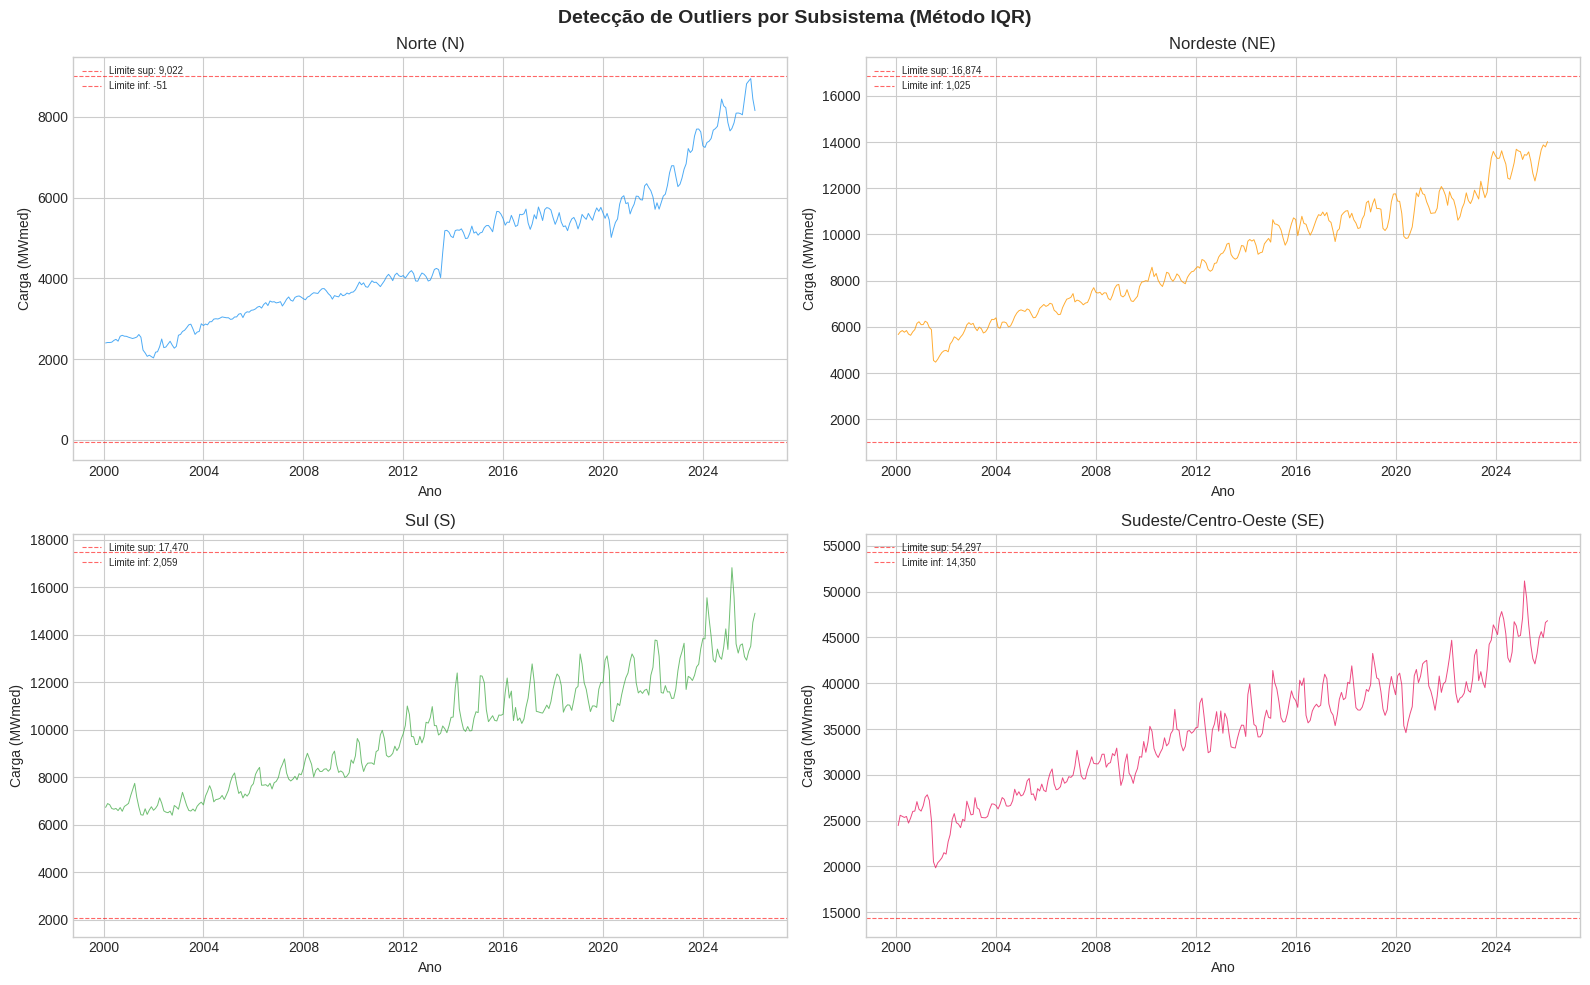

In [ ]:
# Visualização dos outliers por subsistema com boxplot e série temporal
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Detecção de Outliers por Subsistema (Método IQR)', fontsize=14, fontweight='bold')

subsistemas = df[['id_subsistema', 'nom_subsistema']].drop_duplicates().values
cores = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']

for i, (id_sub, nom_sub) in enumerate(subsistemas):
    ax = axes[i // 2, i % 2]
    dados_sub = df[df['id_subsistema'] == id_sub].copy().sort_values('din_instante')
    valores = dados_sub['val_cargaenergiamwmed']

    Q1 = valores.quantile(0.25)
    Q3 = valores.quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    # Plotar série
    ax.plot(dados_sub['din_instante'], valores, color=cores[i], linewidth=0.7, alpha=0.8)

    # Destacar outliers
    mask_out = (valores < limite_inf) | (valores > limite_sup)
    if mask_out.any():
        ax.scatter(dados_sub.loc[mask_out, 'din_instante'], valores[mask_out],
                   color='red', s=40, zorder=5, label='Outliers')

    # Limites IQR
    ax.axhline(y=limite_sup, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label=f'Limite sup: {limite_sup:,.0f}')
    ax.axhline(y=limite_inf, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label=f'Limite inf: {limite_inf:,.0f}')

    ax.set_title(f'{nom_sub} ({id_sub})')
    ax.set_xlabel('Ano')
    ax.set_ylabel('Carga (MWmed)')
    ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()

### Decisão sobre o tratamento de outliers

Ao analisar os outliers identificados pelo método IQR, é importante considerar que, em séries temporais de longo prazo com **tendência de crescimento**, valores recentes naturalmente excedem os limites calculados sobre toda a série histórica. Isso não caracteriza anomalias reais, mas sim a evolução natural do fenômeno.

**Decisão adotada:** Os outliers detectados pelo IQR **não serão removidos nem substituídos**, pois:
1. Refletem o crescimento real e documentado da carga do SIN ao longo de 26 anos.
2. A remoção de pontos extremos em uma série com tendência distorceria os padrões que os modelos precisam capturar.
3. Eventuais anomalias pontuais (como quedas durante a pandemia de 2020) são eventos reais que o modelo deve aprender a lidar.

Esta decisão está alinhada com boas práticas de análise de séries temporais, onde outliers decorrentes de tendência não devem ser tratados como ruído (OLIVEIRA; ABARRACIN; SILVA, 2024).

## 1.6 Construção da série temporal do SIN

Para analisar a carga total do Sistema Interligado Nacional, agregamos os quatro subsistemas (Norte, Nordeste, Sul e Sudeste/Centro-Oeste) somando seus valores de carga para cada mês. O resultado é uma série temporal única com frequência mensal.

**Justificativa:** A agregação por soma é adequada porque a carga total do SIN é a soma das cargas de todos os subsistemas interligados. A definição da data como índice com frequência mensal (`MS` — *Month Start*) é necessária para que as funções de decomposição e autocorrelação do `statsmodels` operem corretamente (OLIVEIRA; ABARRACIN; SILVA, 2024).

In [ ]:
# Agregar carga total do SIN por mês (soma dos 4 subsistemas)
df_sin = df.groupby('din_instante')['val_cargaenergiamwmed'].sum().reset_index()
df_sin.columns = ['data', 'carga_mwmed']

# Definir a data como índice com frequência mensal
df_sin['data'] = pd.to_datetime(df_sin['data'])
df_sin = df_sin.set_index('data')
df_sin.index = df_sin.index.to_period('M').to_timestamp()
df_sin = df_sin.asfreq('MS')

print("=" * 60)
print("SÉRIE TEMPORAL DO SIN — CARGA TOTAL MENSAL")
print("=" * 60)
print(f"\nShape da série agregada: {df_sin.shape}")
print(f"Período: {df_sin.index.min().strftime('%m/%Y')} a {df_sin.index.max().strftime('%m/%Y')}")
print(f"Frequência do índice: {df_sin.index.freq}")
print(f"Valores nulos após agregação: {df_sin.isnull().sum().values[0]}")

print("\n--- Primeiros registros da série do SIN ---")
display(df_sin.head(10))

print("\n--- Estatísticas descritivas da carga total do SIN (MWmed) ---")
display(df_sin.describe())

SÉRIE TEMPORAL DO SIN — CARGA TOTAL MENSAL

Shape da série agregada: (313, 1)
Período: 01/2000 a 01/2026
Frequência do índice: <MonthBegin>
Valores nulos após agregação: 0

--- Primeiros registros da série do SIN ---


,carga_mwmed
data,
2000-01-01,39253.390659
2000-02-01,40665.397845
2000-03-01,40556.063720
2000-04-01,40214.947917
2000-05-01,40408.382258
2000-06-01,39590.820326
2000-07-01,39964.849906
2000-08-01,41074.001075
2000-09-01,41075.071542



--- Estatísticas descritivas da carga total do SIN (MWmed) ---


,carga_mwmed
count,313.000000
mean,58102.761490
std,12640.016692
min,32944.634664
25%,47688.153978
50%,58477.185179
75%,67829.718118
max,89135.166238


---

# **2. Análise Exploratória da Série Temporal**

Nesta seção, conduzimos a investigação exploratória da série temporal de carga do SIN, identificando visualmente e analiticamente suas componentes: tendência, sazonalidade, ciclos e ruído. A análise segue a metodologia proposta por Oliveira, Abarracin e Silva (2024), incluindo visualizações, decomposição, testes de estacionariedade e análise de autocorrelação.

## 2.1 Visualização da série temporal completa

Plotamos a série temporal da carga total do SIN para uma primeira análise visual, buscando identificar padrões gerais de tendência, sazonalidade e possíveis anomalias.

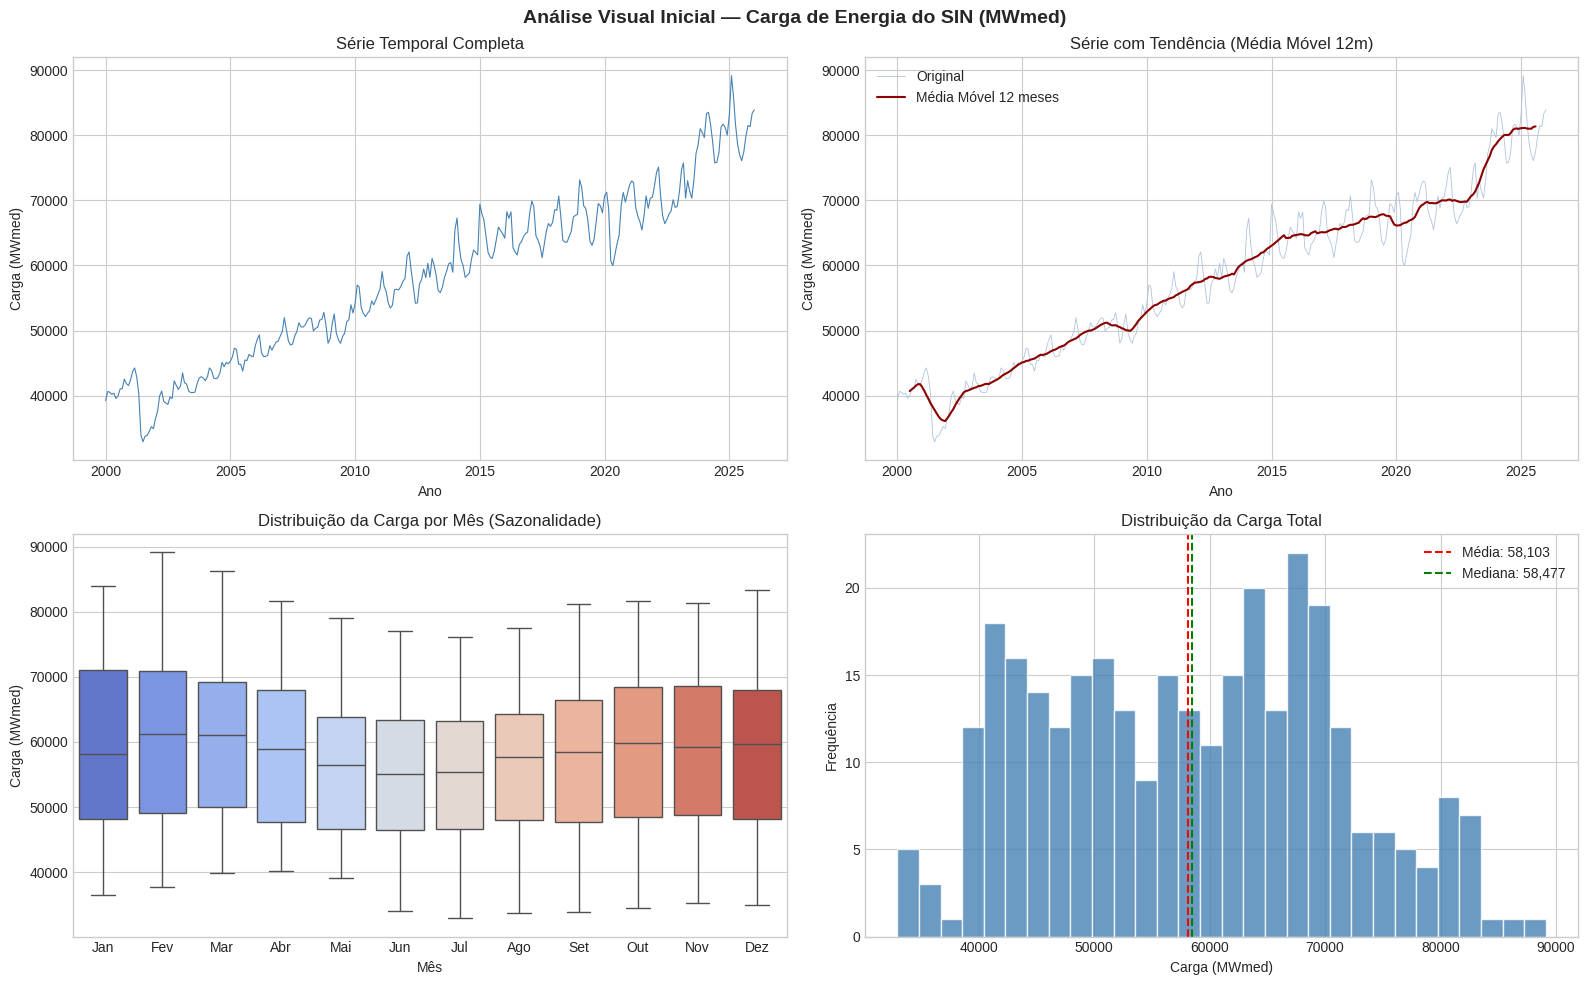

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Análise Visual Inicial — Carga de Energia do SIN (MWmed)', fontsize=14, fontweight='bold')

# 1. Série temporal completa
ax1 = axes[0, 0]
ax1.plot(df_sin.index, df_sin['carga_mwmed'], color='steelblue', linewidth=0.8)
ax1.set_title('Série Temporal Completa')
ax1.set_xlabel('Ano')
ax1.set_ylabel('Carga (MWmed)')
ax1.xaxis.set_major_locator(mdates.YearLocator(5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 2. Série com média móvel de 12 meses (tendência)
ax2 = axes[0, 1]
mm12 = df_sin['carga_mwmed'].rolling(window=12, center=True).mean()
ax2.plot(df_sin.index, df_sin['carga_mwmed'], color='lightsteelblue', linewidth=0.6, label='Original')
ax2.plot(df_sin.index, mm12, color='darkred', linewidth=1.5, label='Média Móvel 12 meses')
ax2.set_title('Série com Tendência (Média Móvel 12m)')
ax2.set_xlabel('Ano')
ax2.set_ylabel('Carga (MWmed)')
ax2.legend()
ax2.xaxis.set_major_locator(mdates.YearLocator(5))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 3. Boxplot por mês (sazonalidade)
ax3 = axes[1, 0]
df_sin_temp = df_sin.copy()
df_sin_temp['mes'] = df_sin_temp.index.month
meses_nomes = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
sns.boxplot(x='mes', y='carga_mwmed', data=df_sin_temp, ax=ax3, palette='coolwarm')
ax3.set_xticklabels(meses_nomes)
ax3.set_title('Distribuição da Carga por Mês (Sazonalidade)')
ax3.set_xlabel('Mês')
ax3.set_ylabel('Carga (MWmed)')

# 4. Histograma da distribuição
ax4 = axes[1, 1]
ax4.hist(df_sin['carga_mwmed'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax4.axvline(df_sin['carga_mwmed'].mean(), color='red', linestyle='--', label=f"Média: {df_sin['carga_mwmed'].mean():,.0f}")
ax4.axvline(df_sin['carga_mwmed'].median(), color='green', linestyle='--', label=f"Mediana: {df_sin['carga_mwmed'].median():,.0f}")
ax4.set_title('Distribuição da Carga Total')
ax4.set_xlabel('Carga (MWmed)')
ax4.set_ylabel('Frequência')
ax4.legend()

plt.tight_layout()
plt.show()

### Observações da análise visual inicial

- **Tendência:** A série apresenta uma tendência de crescimento ao longo dos anos, com a carga média do SIN aumentando de aproximadamente 39.000 MWmed em 2000 para cerca de 80.000 MWmed nos anos mais recentes. A média móvel de 12 meses evidencia essa tendência ascendente.
- **Sazonalidade:** O boxplot por mês revela um padrão sazonal claro, com cargas mais elevadas nos meses de verão (dezembro a março) e valores menores nos meses de inverno (junho a agosto), comportamento consistente com a maior demanda por refrigeração no período quente.
- **Distribuição:** O histograma sugere uma distribuição com certa assimetria, refletindo o crescimento da carga ao longo das décadas.

## 2.2 Visualização por subsistema

Antes de prosseguir com a série agregada, é importante visualizar o comportamento individual de cada subsistema para compreender suas contribuições relativas à carga total do SIN.

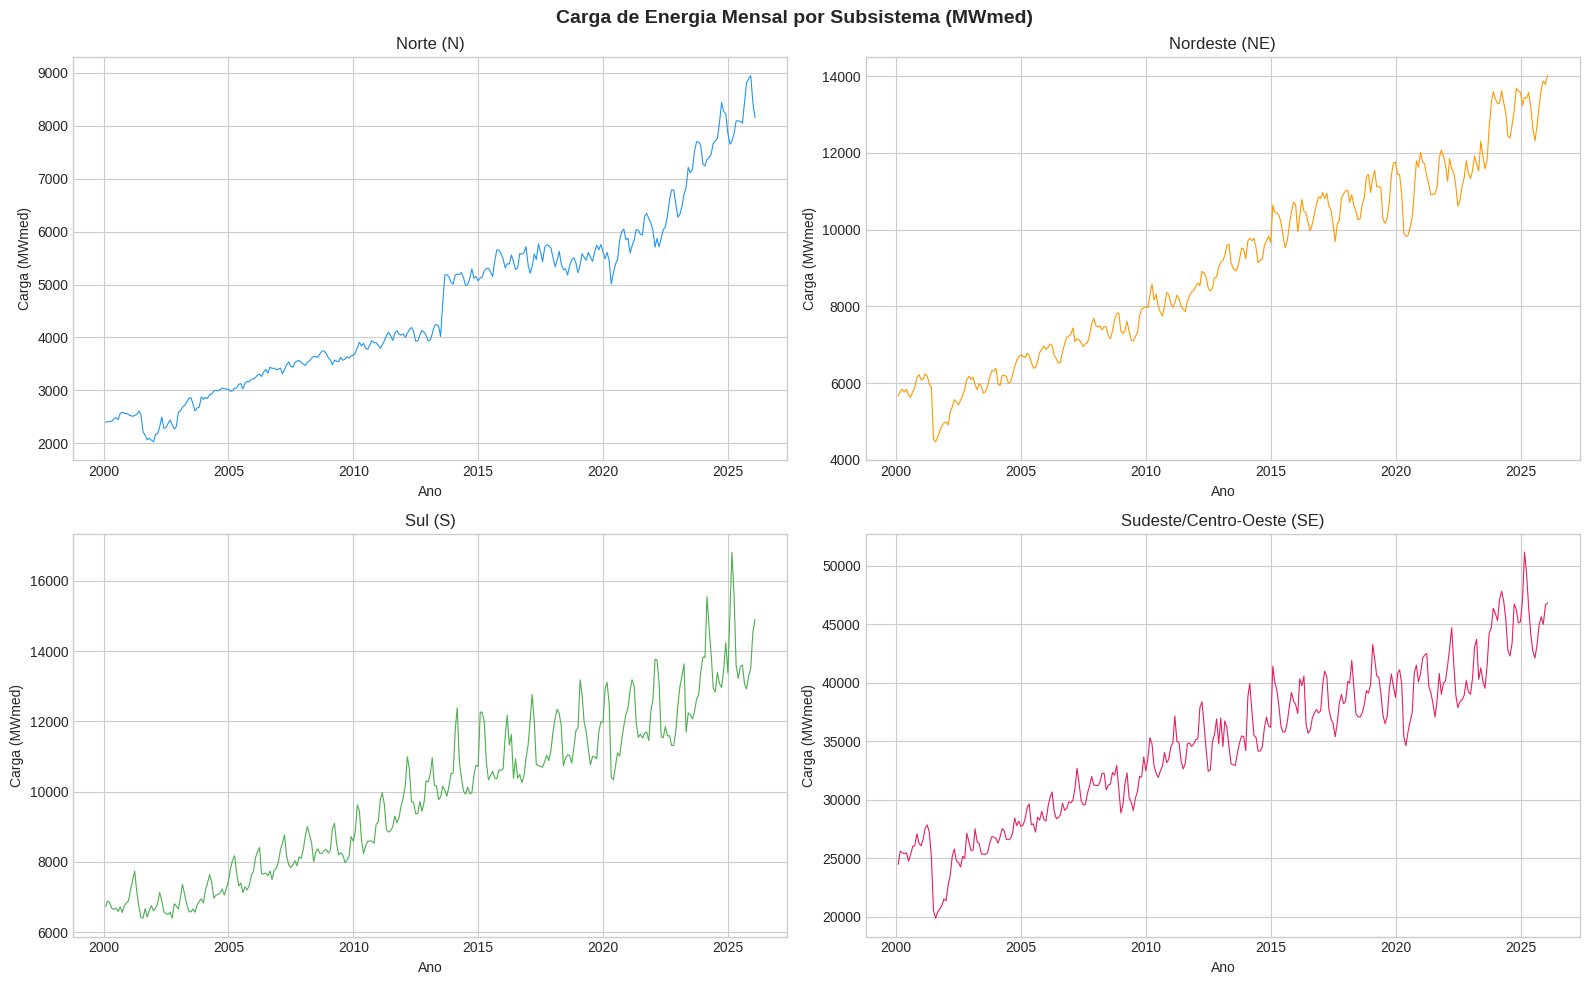


--- Participação média de cada subsistema na carga do SIN ---
  Sudeste/Centro-Oeste: 59.5%
  Sul: 17.0%
  Nordeste: 15.5%
  Norte: 8.0%


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Carga de Energia Mensal por Subsistema (MWmed)', fontsize=14, fontweight='bold')

subsistemas = df[['id_subsistema', 'nom_subsistema']].drop_duplicates().values
cores = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']

for i, (id_sub, nom_sub) in enumerate(subsistemas):
    ax = axes[i // 2, i % 2]
    dados_sub = df[df['id_subsistema'] == id_sub].copy()
    dados_sub = dados_sub.set_index('din_instante').sort_index()
    ax.plot(dados_sub.index, dados_sub['val_cargaenergiamwmed'], color=cores[i], linewidth=0.8)
    ax.set_title(f'{nom_sub} ({id_sub})')
    ax.set_xlabel('Ano')
    ax.set_ylabel('Carga (MWmed)')
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

# Participação média de cada subsistema na carga total
print("\n--- Participação média de cada subsistema na carga do SIN ---")
df_part = df.groupby('nom_subsistema')['val_cargaenergiamwmed'].mean()
df_part_pct = (df_part / df_part.sum() * 100).round(1)
for sub, pct in df_part_pct.sort_values(ascending=False).items():
    print(f"  {sub}: {pct}%")

## 2.3 Decomposição da série temporal

Aplicamos a decomposição da série temporal para separar suas componentes: **tendência**, **sazonalidade** e **resíduo**. Utilizamos tanto o modelo aditivo quanto o multiplicativo para comparação, com período sazonal de 12 meses (OLIVEIRA; ABARRACIN; SILVA, 2024).

**Modelo aditivo:** $Y_t = T_t + S_t + R_t$ — adequado quando a amplitude da sazonalidade é constante ao longo do tempo.

**Modelo multiplicativo:** $Y_t = T_t \times S_t \times R_t$ — adequado quando a amplitude da sazonalidade cresce proporcionalmente à tendência.

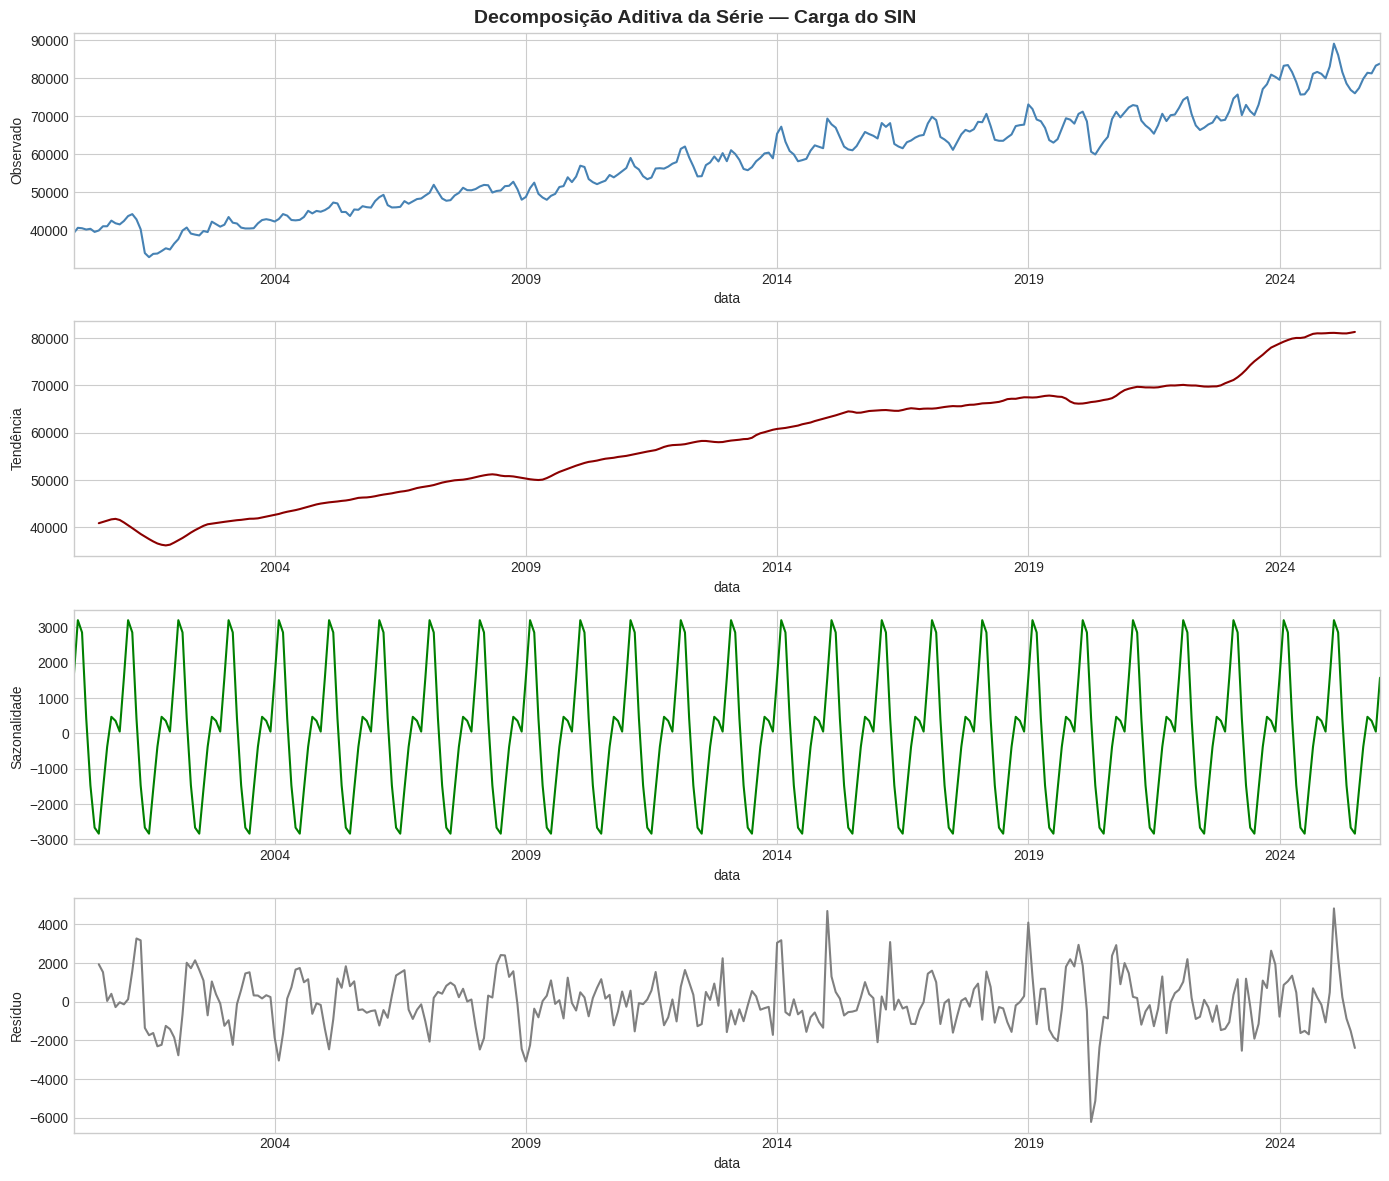

In [ ]:
# Decomposição Aditiva
decomp_aditiva = seasonal_decompose(df_sin['carga_mwmed'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle('Decomposição Aditiva da Série — Carga do SIN', fontsize=14, fontweight='bold')

decomp_aditiva.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_ylabel('Observado')
axes[0].set_title('')

decomp_aditiva.trend.plot(ax=axes[1], color='darkred')
axes[1].set_ylabel('Tendência')
axes[1].set_title('')

decomp_aditiva.seasonal.plot(ax=axes[2], color='green')
axes[2].set_ylabel('Sazonalidade')
axes[2].set_title('')

decomp_aditiva.resid.plot(ax=axes[3], color='gray')
axes[3].set_ylabel('Resíduo')
axes[3].set_title('')

plt.tight_layout()
plt.show()

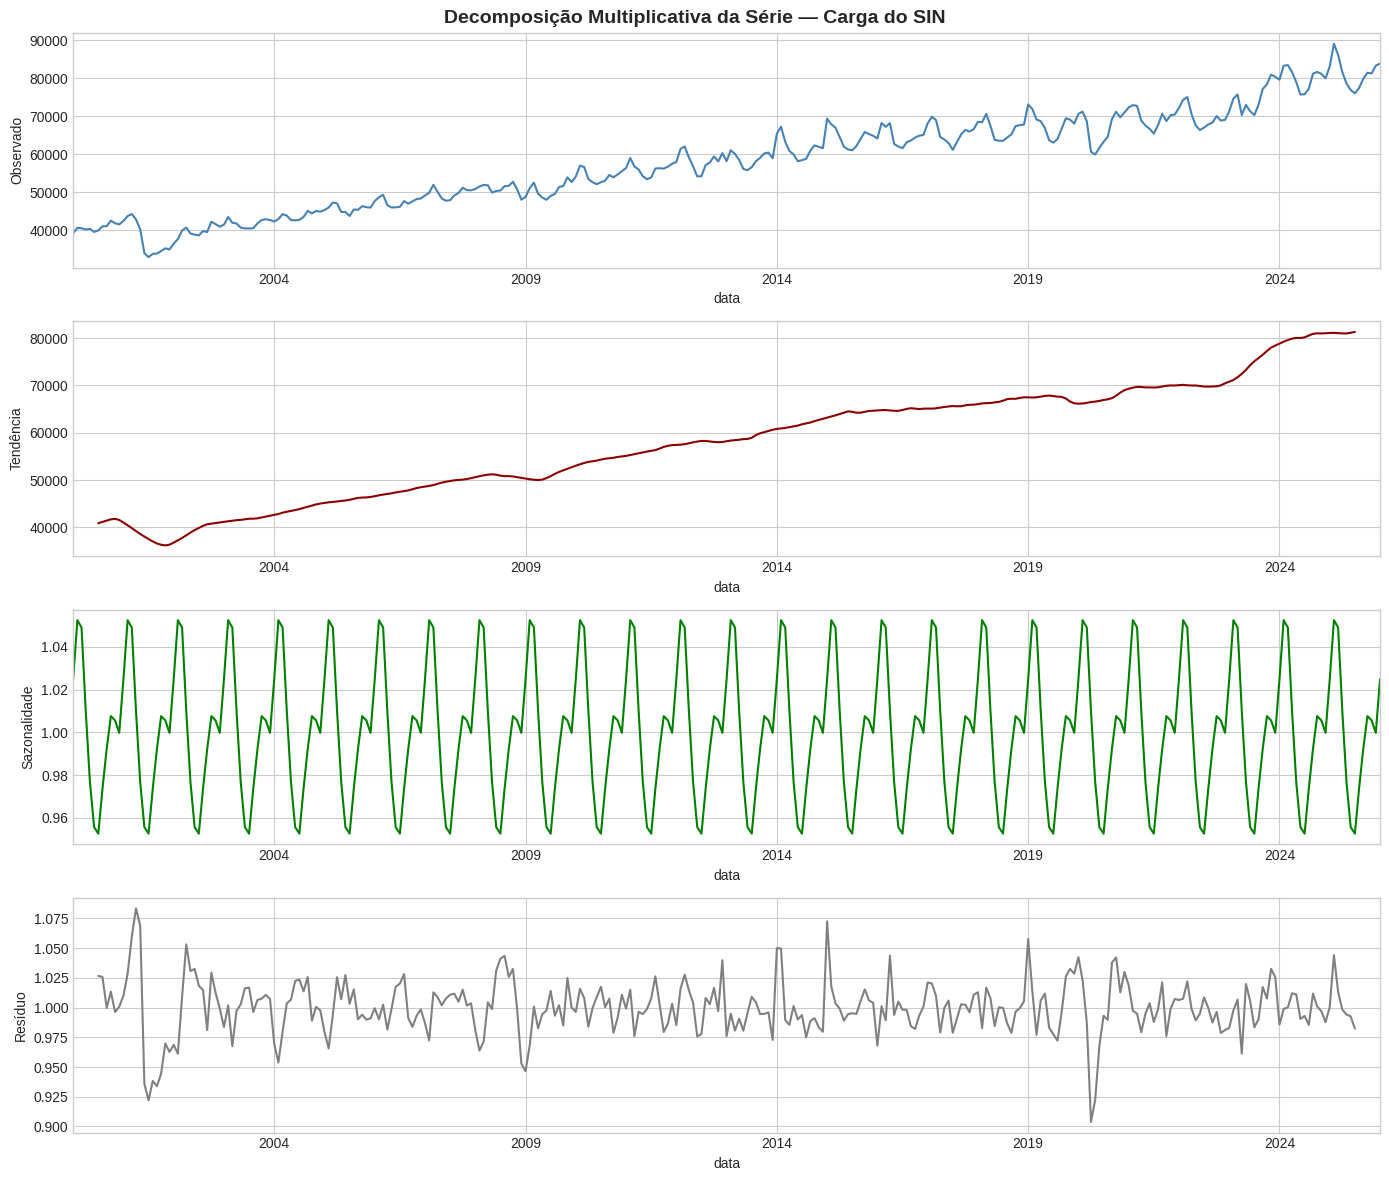


--- Comparação dos resíduos (desvio padrão) ---
Modelo Aditivo    — std resíduo: 1,395.06 MWmed
Modelo Multiplicativo — std resíduo: 0.0229


In [ ]:
# Decomposição Multiplicativa
decomp_multiplicativa = seasonal_decompose(df_sin['carga_mwmed'], model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle('Decomposição Multiplicativa da Série — Carga do SIN', fontsize=14, fontweight='bold')

decomp_multiplicativa.observed.plot(ax=axes[0], color='steelblue')
axes[0].set_ylabel('Observado')
axes[0].set_title('')

decomp_multiplicativa.trend.plot(ax=axes[1], color='darkred')
axes[1].set_ylabel('Tendência')
axes[1].set_title('')

decomp_multiplicativa.seasonal.plot(ax=axes[2], color='green')
axes[2].set_ylabel('Sazonalidade')
axes[2].set_title('')

decomp_multiplicativa.resid.plot(ax=axes[3], color='gray')
axes[3].set_ylabel('Resíduo')
axes[3].set_title('')

plt.tight_layout()
plt.show()

# Comparar resíduos dos dois modelos
print("\n--- Comparação dos resíduos (desvio padrão) ---")
print(f"Modelo Aditivo    — std resíduo: {decomp_aditiva.resid.std():,.2f} MWmed")
print(f"Modelo Multiplicativo — std resíduo: {decomp_multiplicativa.resid.std():,.4f}")

### Observações sobre a decomposição

- **Tendência:** Ambos os modelos evidenciam uma tendência de crescimento contínuo da carga do SIN ao longo dos 26 anos, com desaceleração em alguns períodos (possivelmente crises econômicas de 2008-2009 e efeitos da pandemia de 2020).
- **Sazonalidade:** O componente sazonal revela oscilações regulares de 12 meses, com picos nos meses de verão e vales no inverno, padrão consistente com a climatologia brasileira.
- **Resíduos:** O modelo multiplicativo tende a ser mais adequado quando a amplitude sazonal cresce com a tendência. A comparação dos desvios padrão dos resíduos auxilia na escolha do modelo mais apropriado.
- **Escolha:** Como a carga do SIN dobrou no período analisado e a amplitude das oscilações sazonais também cresceu proporcionalmente, o **modelo multiplicativo** é mais adequado para esta série.

## 2.4 Testes de estacionariedade

A estacionariedade é um pressuposto fundamental para diversos modelos de séries temporais, como ARIMA e SARIMA. Uma série estacionária possui média, variância e autocorrelação constantes ao longo do tempo.

Aplicamos dois testes complementares:
- **Teste ADF (Augmented Dickey-Fuller):** H₀ = a série possui raiz unitária (não estacionária). Rejeitar H₀ (p < 0,05) indica estacionariedade.
- **Teste KPSS:** H₀ = a série é estacionária. Rejeitar H₀ (p < 0,05) indica não estacionariedade.

A utilização conjunta dos dois testes permite uma conclusão mais robusta (OLIVEIRA; ABARRACIN; SILVA, 2024).

In [ ]:
def teste_adf(serie, nome=''):
    """Aplica o teste Augmented Dickey-Fuller e exibe os resultados."""
    resultado = adfuller(serie.dropna(), autolag='AIC')
    print(f"{'='*60}")
    print(f"TESTE ADF — {nome}")
    print(f"{'='*60}")
    print(f"  Estatística ADF:  {resultado[0]:.4f}")
    print(f"  p-valor:          {resultado[1]:.6f}")
    print(f"  Lags utilizados:  {resultado[2]}")
    print(f"  Observações:      {resultado[3]}")
    print(f"  Valores críticos:")
    for chave, valor in resultado[4].items():
        print(f"    {chave}: {valor:.4f}")
    if resultado[1] < 0.05:
        print(f"\n  ✔ Resultado: REJEITA H₀ → Série ESTACIONÁRIA (p={resultado[1]:.6f} < 0.05)")
    else:
        print(f"\n  ✘ Resultado: NÃO rejeita H₀ → Série NÃO ESTACIONÁRIA (p={resultado[1]:.6f} ≥ 0.05)")
    return resultado[1]

def teste_kpss(serie, nome=''):
    """Aplica o teste KPSS e exibe os resultados."""
    resultado = kpss(serie.dropna(), regression='c', nlags='auto')
    print(f"\n{'='*60}")
    print(f"TESTE KPSS — {nome}")
    print(f"{'='*60}")
    print(f"  Estatística KPSS: {resultado[0]:.4f}")
    print(f"  p-valor:          {resultado[1]:.4f}")
    print(f"  Lags utilizados:  {resultado[2]}")
    print(f"  Valores críticos:")
    for chave, valor in resultado[3].items():
        print(f"    {chave}: {valor:.4f}")
    if resultado[1] < 0.05:
        print(f"\n  ✘ Resultado: REJEITA H₀ → Série NÃO ESTACIONÁRIA (p={resultado[1]:.4f} < 0.05)")
    else:
        print(f"\n  ✔ Resultado: NÃO rejeita H₀ → Série ESTACIONÁRIA (p={resultado[1]:.4f} ≥ 0.05)")
    return resultado[1]

# Testes na série original
print("▶ SÉRIE ORIGINAL (Carga Total do SIN)\n")
p_adf_orig = teste_adf(df_sin['carga_mwmed'], 'Série Original')
p_kpss_orig = teste_kpss(df_sin['carga_mwmed'], 'Série Original')

▶ SÉRIE ORIGINAL (Carga Total do SIN)

TESTE ADF — Série Original
  Estatística ADF:  0.4159
  p-valor:          0.982079
  Lags utilizados:  16
  Observações:      296
  Valores críticos:
    1%: -3.4526
    5%: -2.8714
    10%: -2.5720

  ✘ Resultado: NÃO rejeita H₀ → Série NÃO ESTACIONÁRIA (p=0.982079 ≥ 0.05)

TESTE KPSS — Série Original
  Estatística KPSS: 2.6371
  p-valor:          0.0100
  Lags utilizados:  11
  Valores críticos:
    10%: 0.3470
    5%: 0.4630
    2.5%: 0.5740
    1%: 0.7390

  ✘ Resultado: REJEITA H₀ → Série NÃO ESTACIONÁRIA (p=0.0100 < 0.05)


## 2.5 Autocorrelação (ACF) e Autocorrelação Parcial (PACF)

As funções de autocorrelação (ACF) e autocorrelação parcial (PACF) são ferramentas essenciais para identificar a estrutura de dependência temporal na série e orientar a escolha dos parâmetros dos modelos ARIMA/SARIMA (OLIVEIRA; ABARRACIN; SILVA, 2024).

- **ACF:** Mede a correlação entre a série e seus valores defasados (lags). Decaimentos lentos indicam não estacionariedade; picos periódicos indicam sazonalidade.
- **PACF:** Mede a correlação entre a série e um lag específico, removendo o efeito dos lags intermediários. Auxilia na identificação da ordem autorregressiva (p) do modelo.

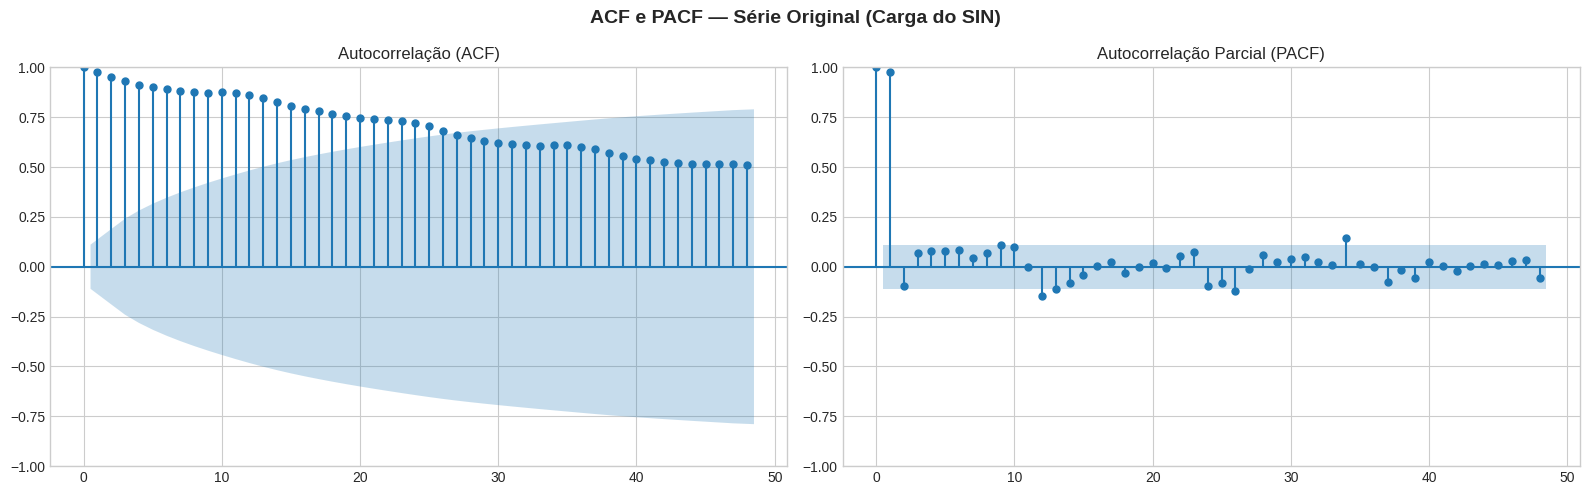

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('ACF e PACF — Série Original (Carga do SIN)', fontsize=14, fontweight='bold')

plot_acf(df_sin['carga_mwmed'].dropna(), lags=48, ax=axes[0], title='Autocorrelação (ACF)')
plot_pacf(df_sin['carga_mwmed'].dropna(), lags=48, ax=axes[1], title='Autocorrelação Parcial (PACF)', method='ywm')

plt.tight_layout()
plt.show()

### Interpretação da ACF e PACF da série original

- **ACF:** O decaimento lento das autocorrelações confirma que a série original **não é estacionária**, pois valores passados possuem forte influência sobre os futuros. Além disso, picos nos lags 12, 24, 36 e 48 evidenciam a **sazonalidade anual** (período de 12 meses).
- **PACF:** O primeiro lag é altamente significativo, com queda abrupta, sugerindo um componente autorregressivo forte. Picos em múltiplos de 12 reforçam a presença do componente sazonal.

Esses resultados indicam a necessidade de **diferenciação** (regular e sazonal) para tornar a série estacionária antes da modelagem.

## 2.6 Transformações para estacionariedade

Dado que a série original não é estacionária, aplicamos as seguintes transformações para torná-la apta à modelagem:

1. **Diferenciação de 1ª ordem (d=1):** Remove a tendência linear da série.
2. **Diferenciação sazonal (D=1, s=12):** Remove o componente sazonal de período 12 meses.
3. **Diferenciação combinada (d=1, D=1):** Remove simultaneamente tendência e sazonalidade.

Após cada transformação, reaplicamos os testes ADF e KPSS para verificar se a estacionariedade foi alcançada, e plotamos as funções ACF/PACF para avaliar a estrutura residual.

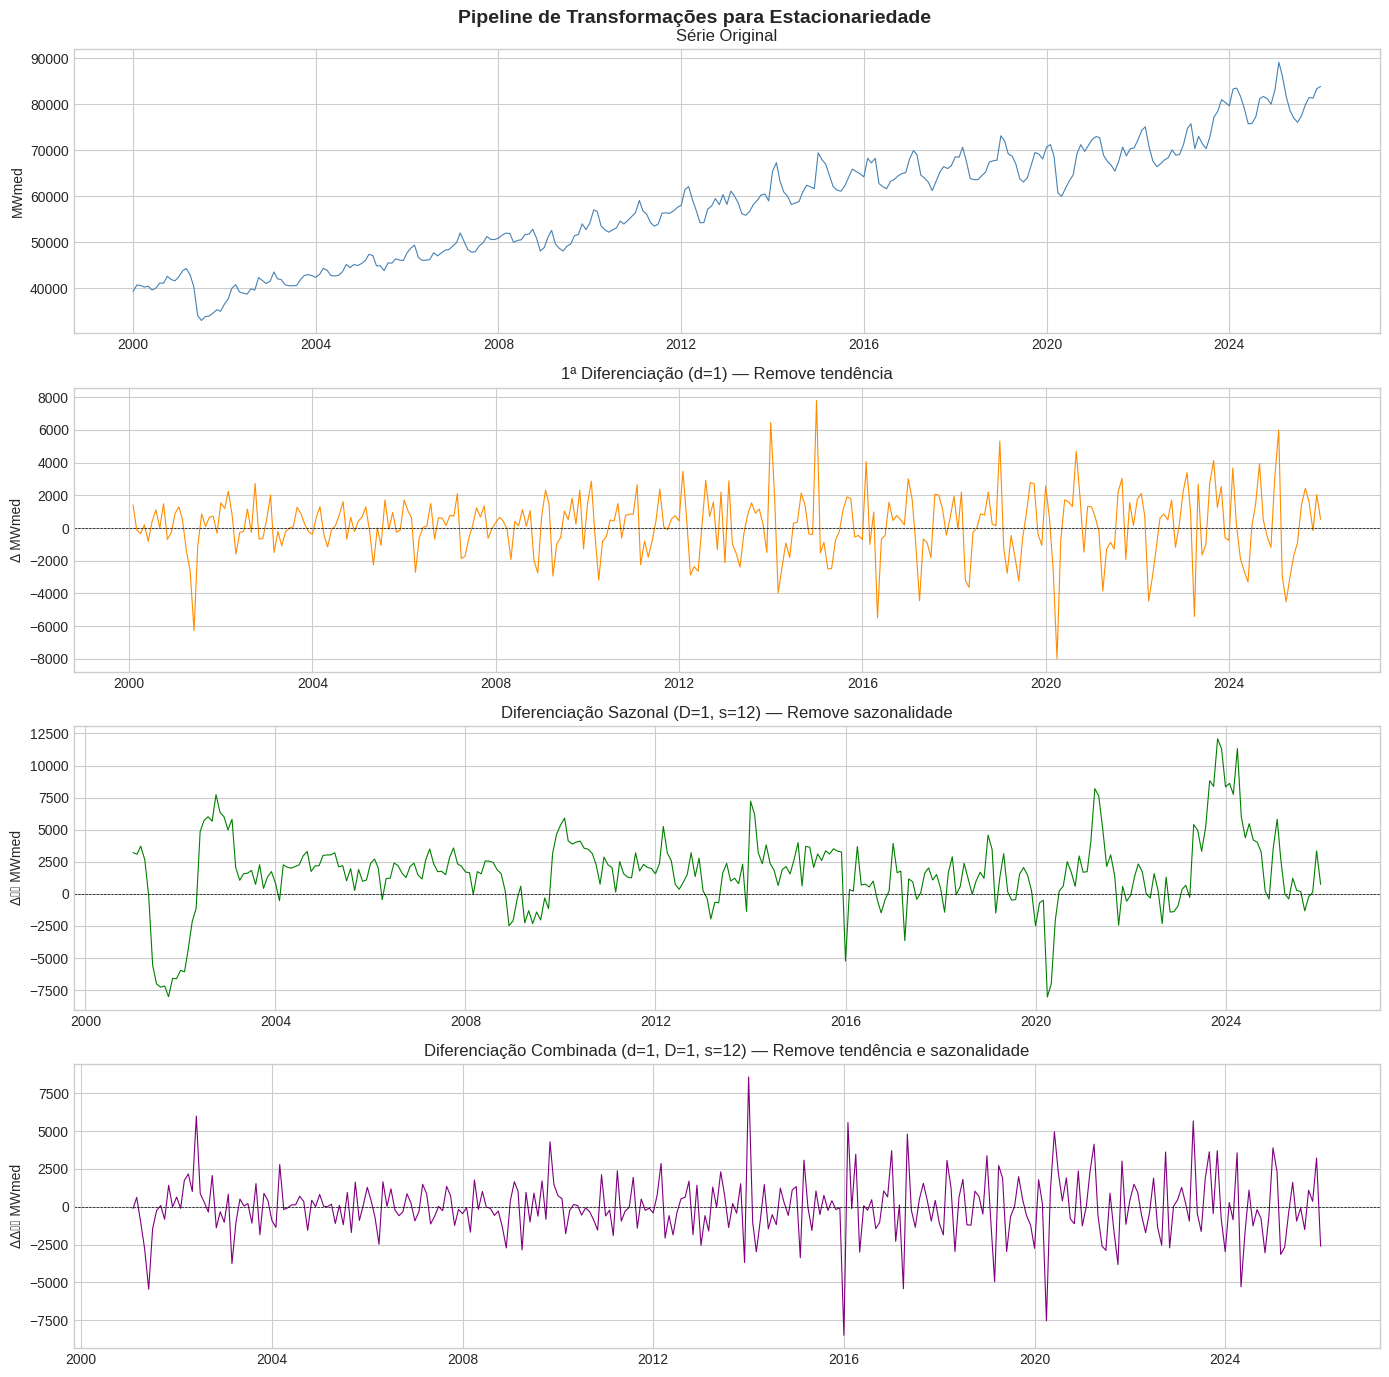

In [ ]:
# --- Diferenciação de 1ª ordem (d=1) ---
df_sin['diff_1'] = df_sin['carga_mwmed'].diff(1)

# --- Diferenciação sazonal (D=1, s=12) ---
df_sin['diff_12'] = df_sin['carga_mwmed'].diff(12)

# --- Diferenciação combinada (d=1, D=1) ---
df_sin['diff_1_12'] = df_sin['carga_mwmed'].diff(12).diff(1)

# Visualizar as transformações
fig, axes = plt.subplots(4, 1, figsize=(14, 14))
fig.suptitle('Pipeline de Transformações para Estacionariedade', fontsize=14, fontweight='bold')

axes[0].plot(df_sin.index, df_sin['carga_mwmed'], color='steelblue', linewidth=0.8)
axes[0].set_title('Série Original')
axes[0].set_ylabel('MWmed')

axes[1].plot(df_sin.index, df_sin['diff_1'], color='darkorange', linewidth=0.8)
axes[1].set_title('1ª Diferenciação (d=1) — Remove tendência')
axes[1].set_ylabel('Δ MWmed')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.5)

axes[2].plot(df_sin.index, df_sin['diff_12'], color='green', linewidth=0.8)
axes[2].set_title('Diferenciação Sazonal (D=1, s=12) — Remove sazonalidade')
axes[2].set_ylabel('Δ₁₂ MWmed')
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=0.5)

axes[3].plot(df_sin.index, df_sin['diff_1_12'], color='purple', linewidth=0.8)
axes[3].set_title('Diferenciação Combinada (d=1, D=1, s=12) — Remove tendência e sazonalidade')
axes[3].set_ylabel('ΔΔ₁₂ MWmed')
axes[3].axhline(y=0, color='black', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# --- Testes de estacionariedade nas séries diferenciadas ---

print("▶ DIFERENCIAÇÃO DE 1ª ORDEM (d=1)\n")
p_adf_d1 = teste_adf(df_sin['diff_1'], 'Diferenciação d=1')
p_kpss_d1 = teste_kpss(df_sin['diff_1'], 'Diferenciação d=1')

print("\n\n▶ DIFERENCIAÇÃO SAZONAL (D=1, s=12)\n")
p_adf_d12 = teste_adf(df_sin['diff_12'], 'Diferenciação D=1 (s=12)')
p_kpss_d12 = teste_kpss(df_sin['diff_12'], 'Diferenciação D=1 (s=12)')

print("\n\n▶ DIFERENCIAÇÃO COMBINADA (d=1, D=1, s=12)\n")
p_adf_d1_12 = teste_adf(df_sin['diff_1_12'], 'Diferenciação d=1, D=1 (s=12)')
p_kpss_d1_12 = teste_kpss(df_sin['diff_1_12'], 'Diferenciação d=1, D=1 (s=12)')

# Resumo
print("\n\n" + "=" * 60)
print("RESUMO DOS TESTES DE ESTACIONARIEDADE")
print("=" * 60)
print(f"{'Série':<35} {'ADF p-valor':<15} {'KPSS p-valor':<15} {'Estacionária?'}")
print("-" * 80)
dados_resumo = [
    ('Original', p_adf_orig, p_kpss_orig),
    ('Diff d=1', p_adf_d1, p_kpss_d1),
    ('Diff D=1 (s=12)', p_adf_d12, p_kpss_d12),
    ('Diff d=1, D=1 (s=12)', p_adf_d1_12, p_kpss_d1_12),
]
for nome, p_adf, p_kpss in dados_resumo:
    estac = "✔ Sim" if (p_adf < 0.05 and p_kpss >= 0.05) else "✘ Não" if (p_adf >= 0.05 or p_kpss < 0.05) else "? Inconclusivo"
    print(f"{nome:<35} {p_adf:<15.6f} {p_kpss:<15.4f} {estac}")

▶ DIFERENCIAÇÃO DE 1ª ORDEM (d=1)

TESTE ADF — Diferenciação d=1
  Estatística ADF:  -5.3069
  p-valor:          0.000005
  Lags utilizados:  15
  Observações:      296
  Valores críticos:
    1%: -3.4526
    5%: -2.8714
    10%: -2.5720

  ✔ Resultado: REJEITA H₀ → Série ESTACIONÁRIA (p=0.000005 < 0.05)

TESTE KPSS — Diferenciação d=1
  Estatística KPSS: 0.0946
  p-valor:          0.1000
  Lags utilizados:  11
  Valores críticos:
    10%: 0.3470
    5%: 0.4630
    2.5%: 0.5740
    1%: 0.7390

  ✔ Resultado: NÃO rejeita H₀ → Série ESTACIONÁRIA (p=0.1000 ≥ 0.05)


▶ DIFERENCIAÇÃO SAZONAL (D=1, s=12)

TESTE ADF — Diferenciação D=1 (s=12)
  Estatística ADF:  -5.5177
  p-valor:          0.000002
  Lags utilizados:  12
  Observações:      288
  Valores críticos:
    1%: -3.4533
    5%: -2.8716
    10%: -2.5721

  ✔ Resultado: REJEITA H₀ → Série ESTACIONÁRIA (p=0.000002 < 0.05)

TESTE KPSS — Diferenciação D=1 (s=12)
  Estatística KPSS: 0.1352
  p-valor:          0.1000
  Lags utilizados:  9


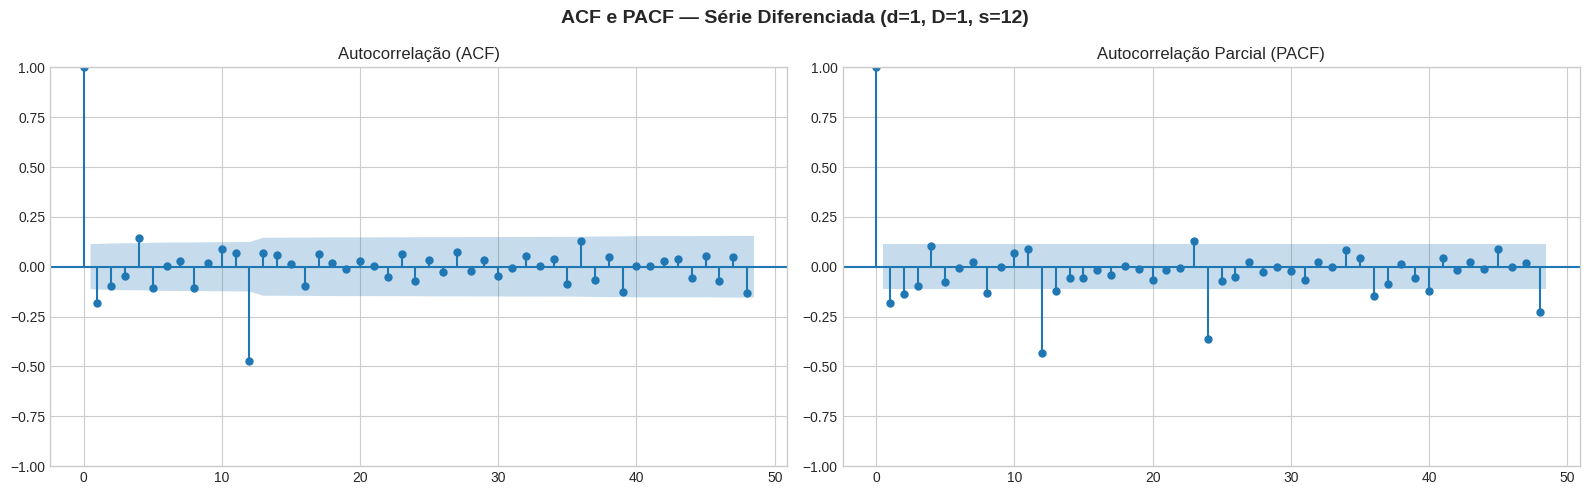

In [ ]:
# ACF e PACF da série com diferenciação combinada (d=1, D=1, s=12)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('ACF e PACF — Série Diferenciada (d=1, D=1, s=12)', fontsize=14, fontweight='bold')

serie_diff = df_sin['diff_1_12'].dropna()
plot_acf(serie_diff, lags=48, ax=axes[0], title='Autocorrelação (ACF)')
plot_pacf(serie_diff, lags=48, ax=axes[1], title='Autocorrelação Parcial (PACF)', method='ywm')

plt.tight_layout()
plt.show()

### Interpretação das transformações e testes

- **Diferenciação de 1ª ordem (d=1):** Remove a tendência de crescimento. A série resultante oscila em torno de zero, mas ainda pode apresentar autocorrelações sazonais.
- **Diferenciação sazonal (D=1, s=12):** Remove o padrão sazonal anual, mas a tendência de longo prazo pode persistir.
- **Diferenciação combinada (d=1, D=1, s=12):** É a transformação mais eficaz, removendo simultaneamente tendência e sazonalidade. A tabela resumo dos testes ADF e KPSS confirma se a estacionariedade foi alcançada.

A ACF e PACF da série diferenciada (d=1, D=1) apresentam uma estrutura residual que será útil para orientar a escolha dos parâmetros (p, d, q) × (P, D, Q, s) do modelo SARIMA na Entrega 3.

**Conclusão do pipeline de análise:** A série original de carga do SIN possui forte tendência de crescimento e sazonalidade anual bem definida. Após diferenciação de 1ª ordem e diferenciação sazonal de período 12, a série atinge a estacionariedade necessária para a aplicação de modelos autorregressivos.

---

# **3. Revisão Bibliográfica**

Nesta seção, apresentamos uma síntese descritiva de trabalhos relacionados à previsão de carga de energia elétrica por meio de séries temporais, com o objetivo de identificar estratégias e técnicas adequadas para a modelagem da série do SIN.

## 3.1 Modelos clássicos de séries temporais

Segundo Oliveira, Abarracin e Silva (2024), os modelos da família ARIMA — em especial o **SARIMA** (Seasonal ARIMA) — são amplamente utilizados para séries temporais com componentes sazonais bem definidos. O modelo SARIMA incorpora parâmetros sazonais (P, D, Q, s) além dos parâmetros regulares (p, d, q), sendo particularmente adequado para séries de consumo de energia que apresentam sazonalidade anual. Os autores destacam que a metodologia Box-Jenkins, que envolve identificação, estimação e verificação diagnóstica, continua sendo referência para a modelagem de séries temporais univariadas.

Oliveira (2026b; 2026c), em seus repositórios de séries temporais aplicadas ao varejo, demonstra a aplicação prática de modelos SARIMA e de suavização exponencial (Holt-Winters) em séries com tendência e sazonalidade, evidenciando a importância da etapa de diferenciação e análise de autocorrelação para a definição dos parâmetros do modelo.

## 3.2 Abordagens baseadas em machine learning

Pejuca (2026) propõe uma abordagem comparativa entre o modelo ARIMA e o algoritmo **XGBoost** para previsão de séries temporais. O trabalho demonstra que modelos de machine learning, como o XGBoost e Random Forest, podem capturar relações não lineares nos dados que os modelos clássicos não conseguem, sendo especialmente úteis quando há variáveis exógenas (como temperatura, PIB, feriados) que influenciam o comportamento da série. Entretanto, esses modelos exigem engenharia de atributos cuidadosa, incluindo a criação de features temporais (lags, médias móveis, variáveis sazonais).

## 3.3 Previsão de carga de energia elétrica

A previsão de carga de energia é um tema amplamente estudado na literatura. Segundo dados do ONS (2026), a carga do SIN apresenta forte dependência de fatores climáticos e econômicos, o que torna a modelagem desafiadora. Conforme a EPE (2024), o crescimento do consumo de energia elétrica no Brasil tem sido acompanhado por mudanças estruturais, como a expansão da geração distribuída e a micro e minigeração (MMGD), que alteram os padrões tradicionais de demanda.

A aplicação de modelos de suavização exponencial, como o **Holt-Winters**, é recomendada por Oliveira, Abarracin e Silva (2024) para séries com tendência e sazonalidade, podendo ser utilizada tanto na versão aditiva quanto multiplicativa, conforme a natureza dos componentes identificados na análise exploratória.

## 3.4 Síntese e técnicas selecionadas para a Entrega 3

Com base na revisão bibliográfica e na análise exploratória realizada, as seguintes técnicas são consideradas as mais adequadas para a modelagem da série de carga do SIN:

| Técnica | Justificativa |
|---------|---------------|
| **SARIMA** | Modelo clássico ideal para séries com tendência e sazonalidade bem definida. Os parâmetros podem ser identificados a partir da ACF/PACF da série diferenciada. |
| **Holt-Winters (multiplicativo)** | Suavização exponencial tripla, adequada para capturar tendência e sazonalidade multiplicativa, como observado na decomposição. |
| **XGBoost / ML** | Abordagem complementar que pode capturar não linearidades, com engenharia de atributos baseada em lags e variáveis temporais. |

A comparação entre essas técnicas será realizada na Entrega 3 por meio de métricas como MAE, RMSE e MAPE, conforme proposto nos objetivos específicos do projeto.

---

# **Entrega 3 — Modelo Base**

---

# **4. Discussão e Análise da Qualidade dos Dados**

Antes de prosseguir para a modelagem, é fundamental discutir a qualidade, as limitações e as simplificações adotadas no tratamento dos dados.

## 4.1 Qualidade da base

A base de Carga de Energia Mensal do ONS (2026) apresenta **boa qualidade geral**:
- Não foram encontrados valores nulos, registros duplicados nem gaps temporais (conforme verificado nas seções 1.3 e 1.4).
- Os dados abrangem mais de 26 anos de história (Jan/2000 a Jan/2026), totalizando 313 observações mensais após agregação — volume adequado para modelagem de séries temporais com sazonalidade anual.
- A fonte é oficial e os dados passam por processo de consistência recorrente do ONS.

## 4.2 Limitações identificadas

1. **Mudanças metodológicas ao longo do tempo:** Conforme documentação do ONS (2026), a forma de apuração da carga mudou em três momentos distintos (antes de 2015, de 2015 a 2021, e a partir de 2023 com inclusão da MMGD). Isso pode introduzir quebras estruturais na série que não refletem variações reais de demanda.
2. **Ausência de variáveis exógenas:** A base contém apenas a carga e a data, sem variáveis explicativas como temperatura, PIB, tarifas ou feriados, que sabidamente influenciam o consumo de energia (EPE, 2024).
3. **Granularidade mensal:** A resolução mensal limita a captura de padrões intra-mês (dias úteis vs. finais de semana, horários de pico).
4. **Agregação do SIN:** Ao somar os quatro subsistemas, perdem-se diferenças regionais significativas (ex.: sazonalidade distinta do Norte vs. Sul).

## 4.3 Simplificações adotadas

- **Agregação por soma:** Optou-se por trabalhar com a carga total do SIN para simplificar a modelagem univariada, alinhada ao escopo do projeto.
- **Outliers mantidos:** Conforme decisão documentada na seção 1.5, valores extremos decorrentes da tendência de crescimento foram preservados.
- **Sem variáveis exógenas:** Os modelos aplicados nesta entrega (SARIMA e Holt-Winters) são univariados, utilizando apenas a série histórica da carga.

Estas limitações e simplificações serão consideradas na interpretação dos resultados e poderão ser endereçadas na Entrega 4 com a inclusão de modelos multivariados ou de machine learning.

# **5. Divisão dos Dados**

Para avaliar a capacidade preditiva dos modelos, dividimos a série temporal em dois conjuntos de forma **cronológica** (sem embaralhamento), respeitando a ordem temporal dos dados:

- **Treino (~80%):** Utilizado para o modelo aprender os padrões da série.
- **Teste (~20%):** Utilizado para avaliar a capacidade de generalização do modelo em dados nunca vistos.

A divisão cronológica é obrigatória em séries temporais para evitar vazamento de informação futura para o modelo (OLIVEIRA; ABARRACIN; SILVA, 2024).

DIVISÃO DOS DADOS — TREINO / TESTE

Total de observações: 313
Treino: 250 meses (79.9%) — 01/2000 a 10/2020
Teste:  63 meses (20.1%) — 11/2020 a 01/2026


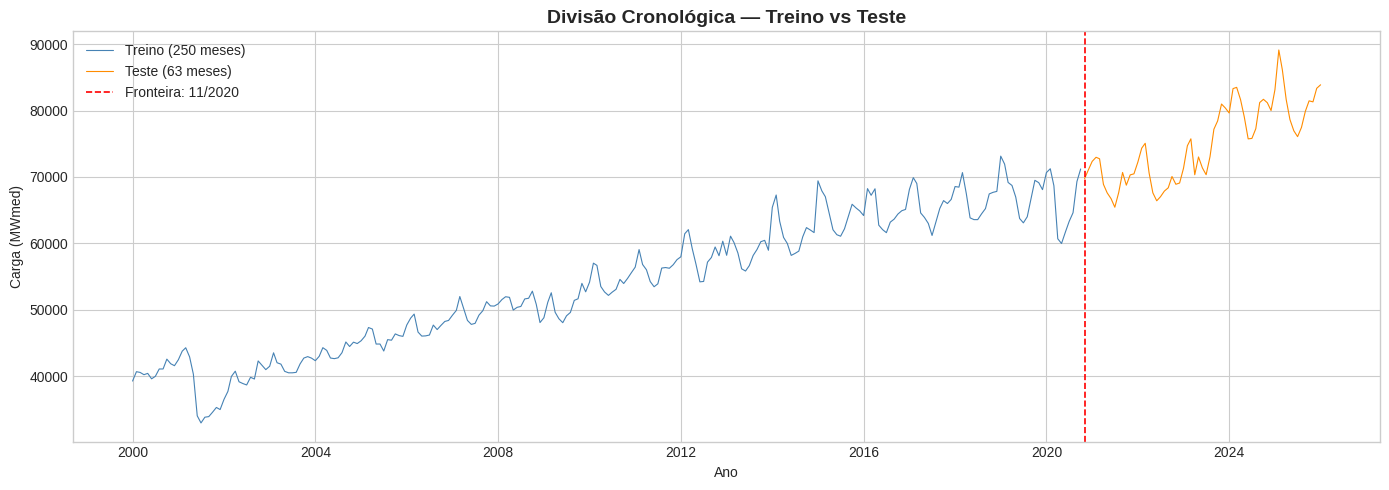

In [ ]:
# Divisão cronológica treino/teste (80/20)
n = len(df_sin)
split_idx = int(n * 0.80)
train = df_sin['carga_mwmed'].iloc[:split_idx]
test = df_sin['carga_mwmed'].iloc[split_idx:]

print("=" * 60)
print("DIVISÃO DOS DADOS — TREINO / TESTE")
print("=" * 60)
print(f"\nTotal de observações: {n}")
print(f"Treino: {len(train)} meses ({len(train)/n*100:.1f}%) — {train.index.min().strftime('%m/%Y')} a {train.index.max().strftime('%m/%Y')}")
print(f"Teste:  {len(test)} meses ({len(test)/n*100:.1f}%) — {test.index.min().strftime('%m/%Y')} a {test.index.max().strftime('%m/%Y')}")

# Visualização da divisão
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train, color='steelblue', linewidth=0.8, label=f'Treino ({len(train)} meses)')
ax.plot(test.index, test, color='darkorange', linewidth=0.8, label=f'Teste ({len(test)} meses)')
ax.axvline(x=test.index[0], color='red', linestyle='--', linewidth=1.2, label=f'Fronteira: {test.index[0].strftime("%m/%Y")}')
ax.set_title('Divisão Cronológica — Treino vs Teste', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Carga (MWmed)')
ax.legend()
plt.tight_layout()
plt.show()

# **6. Definição das Técnicas e Implementação dos Modelos**

Com base na revisão bibliográfica (seção 3) e nos resultados da análise exploratória (seção 2), selecionamos dois modelos estatísticos para a previsão da carga do SIN:

1. **SARIMA** — Seasonal Autoregressive Integrated Moving Average
2. **Holt-Winters Multiplicativo** — Suavização Exponencial Tripla

## 6.1 Modelo SARIMA

O modelo SARIMA estende o ARIMA incorporando componentes sazonais, sendo denotado por **SARIMA(p,d,q)×(P,D,Q,s)**, onde:
- **(p, d, q):** Parâmetros da parte regular (autorregressivo, diferenciação, média móvel)
- **(P, D, Q, s):** Parâmetros da parte sazonal, com período *s*

Da análise exploratória (seção 2), já determinamos:
- **d = 1** (diferenciação de 1ª ordem remove a tendência)
- **D = 1** (diferenciação sazonal remove a sazonalidade)
- **s = 12** (período sazonal anual)

Os parâmetros (p, q, P, Q) serão identificados automaticamente via `auto_arima` da biblioteca `pmdarima`, que realiza uma busca stepwise minimizando o critério AIC (OLIVEIRA; ABARRACIN; SILVA, 2024).

In [ ]:
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

def calcular_mape(y_real, y_pred):
    """Calcula o Mean Absolute Percentage Error (MAPE)."""
    return np.mean(np.abs((y_real - y_pred) / y_real)) * 100

def calcular_metricas(y_real, y_pred, nome_modelo=''):
    """Calcula e exibe MAE, RMSE e MAPE."""
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mape = calcular_mape(y_real, y_pred)
    print(f"\n{'='*60}")
    print(f"MÉTRICAS DE DESEMPENHO — {nome_modelo}")
    print(f"{'='*60}")
    print(f"  MAE  (Mean Absolute Error):          {mae:,.2f} MWmed")
    print(f"  RMSE (Root Mean Squared Error):       {rmse:,.2f} MWmed")
    print(f"  MAPE (Mean Absolute Percentage Error): {mape:.2f}%")
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

print("Funções de métricas definidas.")

Funções de métricas definidas.


### 6.1.1 Identificação automática dos parâmetros (auto_arima)

Utilizamos o `auto_arima` para buscar os melhores parâmetros (p, q, P, Q) via minimização do critério AIC, com d=1, D=1 e s=12 fixos conforme a análise exploratória.

In [ ]:
print("Buscando melhores parâmetros SARIMA com auto_arima...")
print("(isso pode levar alguns minutos)\n")

modelo_auto = auto_arima(
    train,
    d=1,               # diferenciação regular (confirmada pelo ADF)
    D=1,               # diferenciação sazonal
    seasonal=True,
    m=12,              # período sazonal = 12 meses
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    stepwise=True,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    information_criterion='aic',
    n_fits=50
)

print(f"\n{'='*60}")
print("MELHOR MODELO IDENTIFICADO")
print(f"{'='*60}")
print(modelo_auto.summary())

Buscando melhores parâmetros SARIMA com auto_arima...
(isso pode levar alguns minutos)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=4249.267, Time=0.14 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=4221.137, Time=0.46 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=4196.569, Time=1.25 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=4245.207, Time=0.12 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=4186.667, Time=3.26 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=4219.877, Time=0.27 sec
 ARIMA(0,1,1)(2,1,1)[12]             : AIC=4187.843, Time=5.13 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=4187.405, Time=4.90 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=4185.420, Time=2.50 sec
 ARIMA(0,1,0)(0,1,2)[12]             : AIC=4187.680, Time=3.09 sec
 ARIMA(1,1,1)(0,1,2)[12]             : AIC=4186.987, Time=4.91 sec
 ARIMA(0,1,2)(0,1,2)[12]             : AIC=4186.769, Time=1.80 sec
 ARIMA(1,1,0)(0,1,2)[12]             : AIC=4185.859, Time=1.57 se

### 6.1.2 Ajuste e previsão do modelo SARIMA

Ajustamos o modelo SARIMA com os parâmetros identificados no conjunto de treino e realizamos a previsão para o período de teste.

Parâmetros SARIMA: order=(0, 1, 1), seasonal_order=(0, 1, 2, 12)
                                        SARIMAX Results                                        
Dep. Variable:                             carga_mwmed   No. Observations:                  250
Model:             SARIMAX(0, 1, 1)x(0, 1, [1, 2], 12)   Log Likelihood               -1834.257
Date:                                 Sun, 31 May 2026   AIC                           3676.514
Time:                                         15:02:55   BIC                           3689.922
Sample:                                     01-01-2000   HQIC                          3681.934
                                          - 10-01-2020                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1    

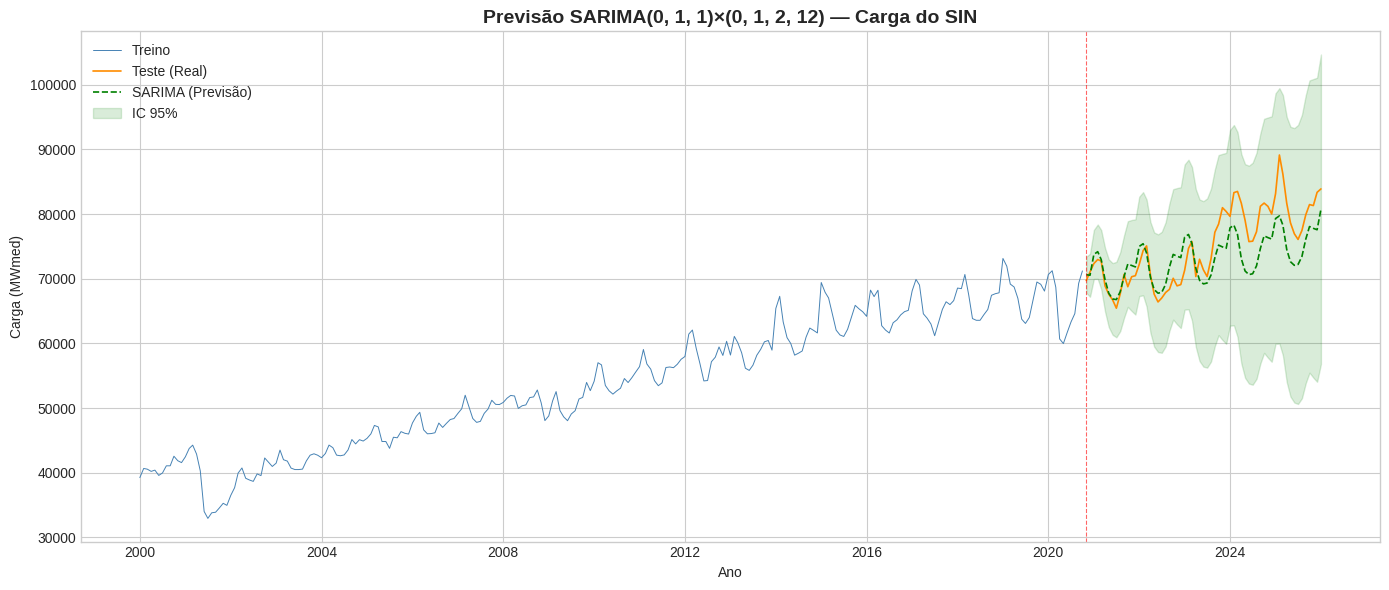


MÉTRICAS DE DESEMPENHO — SARIMA(0, 1, 1)×(0, 1, 2, 12)
  MAE  (Mean Absolute Error):          3,311.81 MWmed
  RMSE (Root Mean Squared Error):       4,057.31 MWmed
  MAPE (Mean Absolute Percentage Error): 4.26%


In [ ]:
# Extrair parâmetros do auto_arima
order = modelo_auto.order
seasonal_order = modelo_auto.seasonal_order
print(f"Parâmetros SARIMA: order={order}, seasonal_order={seasonal_order}")

# Ajustar modelo SARIMAX no conjunto de treino
modelo_sarima = SARIMAX(
    train,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
resultado_sarima = modelo_sarima.fit(disp=False)
print(resultado_sarima.summary())

# Previsão no período de teste
n_forecast = len(test)
previsao_sarima = resultado_sarima.get_forecast(steps=n_forecast)
pred_sarima = previsao_sarima.predicted_mean
pred_sarima.index = test.index
ic_sarima = previsao_sarima.conf_int()
ic_sarima.index = test.index

# Visualização
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.index, train, color='steelblue', linewidth=0.7, label='Treino')
ax.plot(test.index, test, color='darkorange', linewidth=1.2, label='Teste (Real)')
ax.plot(pred_sarima.index, pred_sarima, color='green', linewidth=1.2, linestyle='--', label='SARIMA (Previsão)')
ax.fill_between(ic_sarima.index, ic_sarima.iloc[:, 0], ic_sarima.iloc[:, 1], color='green', alpha=0.15, label='IC 95%')
ax.axvline(x=test.index[0], color='red', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_title(f'Previsão SARIMA{order}×{seasonal_order} — Carga do SIN', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Carga (MWmed)')
ax.legend()
plt.tight_layout()
plt.show()

# Métricas
metricas_sarima = calcular_metricas(test, pred_sarima, f'SARIMA{order}×{seasonal_order}')

### 6.1.3 Diagnóstico dos resíduos do SARIMA

O diagnóstico dos resíduos é essencial para validar as premissas do modelo. Um bom modelo deve produzir resíduos que se comportem como ruído branco: sem autocorrelação, com distribuição aproximadamente normal e variância constante (OLIVEIRA; ABARRACIN; SILVA, 2024).

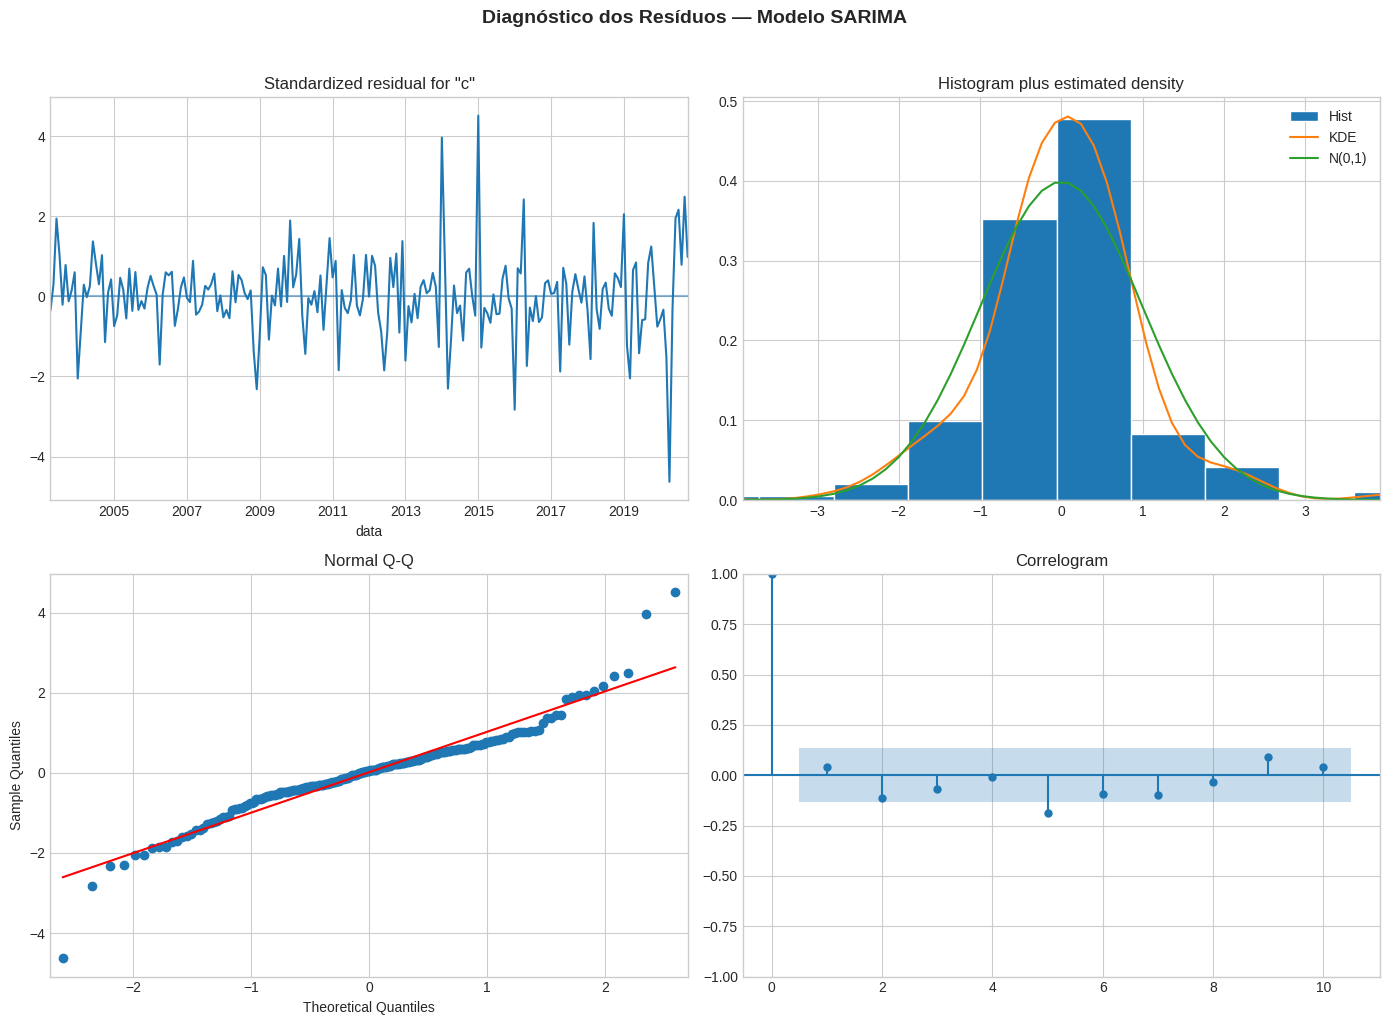


--- Teste de Ljung-Box (H₀: resíduos são ruído branco) ---


,lb_stat,lb_pvalue
12,19.293211,0.081694
24,33.066125,0.102686


  Lag 12: p=0.0817 → ✔ Não rejeita H₀ (resíduos sem autocorrelação)
  Lag 24: p=0.1027 → ✔ Não rejeita H₀ (resíduos sem autocorrelação)


In [ ]:
# Diagnóstico dos resíduos do SARIMA
fig = resultado_sarima.plot_diagnostics(figsize=(14, 10))
fig.suptitle('Diagnóstico dos Resíduos — Modelo SARIMA', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Teste de Ljung-Box para autocorrelação dos resíduos
from statsmodels.stats.diagnostic import acorr_ljungbox
residuos = resultado_sarima.resid
lb_test = acorr_ljungbox(residuos, lags=[12, 24], return_df=True)
print("\n--- Teste de Ljung-Box (H₀: resíduos são ruído branco) ---")
display(lb_test)
for _, row in lb_test.iterrows():
    lag = int(row.name)
    p = row['lb_pvalue']
    if p > 0.05:
        print(f"  Lag {lag}: p={p:.4f} → ✔ Não rejeita H₀ (resíduos sem autocorrelação)")
    else:
        print(f"  Lag {lag}: p={p:.4f} → ✘ Rejeita H₀ (resíduos com autocorrelação residual)")

## 6.2 Modelo Holt-Winters Multiplicativo

O modelo de **Suavização Exponencial Tripla** (Holt-Winters) captura três componentes da série temporal: **nível**, **tendência** e **sazonalidade**. A versão multiplicativa é indicada quando a amplitude da sazonalidade cresce proporcionalmente ao nível da série — exatamente o padrão observado na decomposição da seção 2.3 (OLIVEIRA; ABARRACIN; SILVA, 2024).

O modelo utiliza três parâmetros de suavização (α, β, γ) que controlam o peso dado às observações mais recentes para cada componente. Segundo Hyndman e Athanasopoulos (2021), o Holt-Winters multiplicativo é uma escolha natural para séries de demanda de energia com sazonalidade crescente.

MODELO HOLT-WINTERS MULTIPLICATIVO — PARÂMETROS ESTIMADOS
  α (nível):       1.0000
  β (tendência):   0.0000
  γ (sazonalidade): 0.0000
  AIC: 3631.28
  BIC: 3687.62


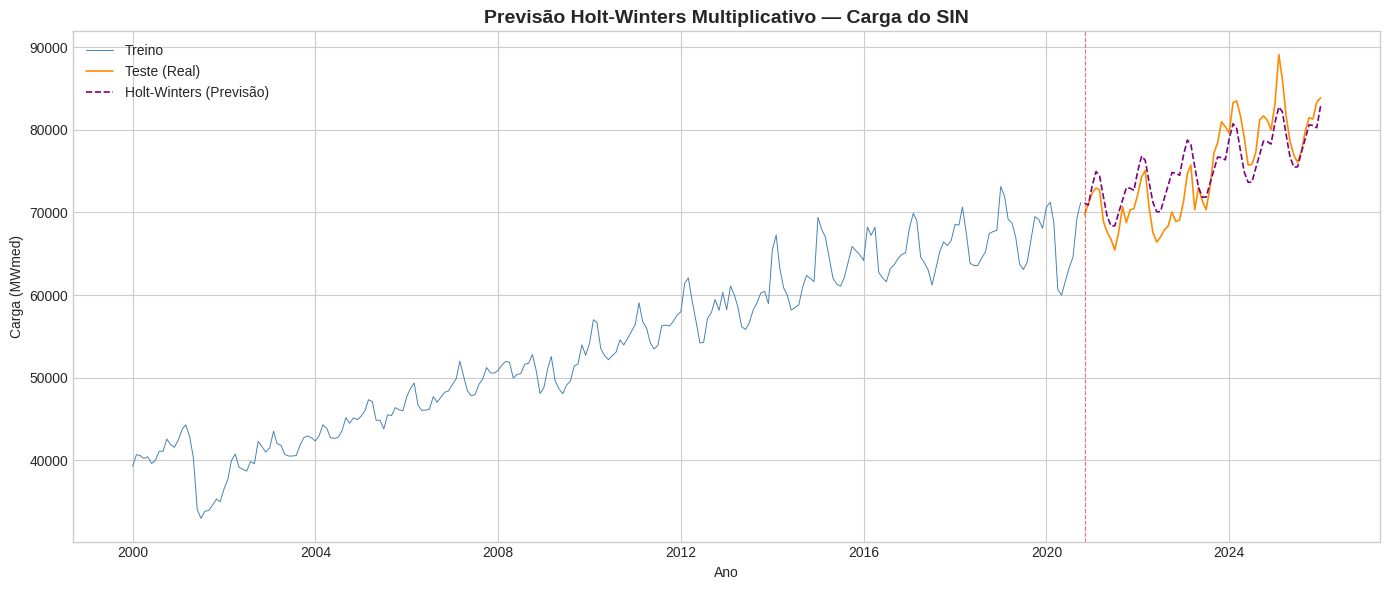


MÉTRICAS DE DESEMPENHO — Holt-Winters Multiplicativo
  MAE  (Mean Absolute Error):          2,586.95 MWmed
  RMSE (Root Mean Squared Error):       3,009.31 MWmed
  MAPE (Mean Absolute Percentage Error): 3.48%


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Ajustar Holt-Winters Multiplicativo no treino
modelo_hw = ExponentialSmoothing(
    train,
    trend='mul',
    seasonal='mul',
    seasonal_periods=12,
    use_boxcox=False,
    initialization_method='estimated'
)
resultado_hw = modelo_hw.fit(optimized=True)

print("=" * 60)
print("MODELO HOLT-WINTERS MULTIPLICATIVO — PARÂMETROS ESTIMADOS")
print("=" * 60)
print(f"  α (nível):       {resultado_hw.params['smoothing_level']:.4f}")
print(f"  β (tendência):   {resultado_hw.params['smoothing_trend']:.4f}")
print(f"  γ (sazonalidade): {resultado_hw.params['smoothing_seasonal']:.4f}")
print(f"  AIC: {resultado_hw.aic:.2f}")
print(f"  BIC: {resultado_hw.bic:.2f}")

# Previsão no período de teste
pred_hw = resultado_hw.forecast(steps=len(test))
pred_hw.index = test.index

# Visualização
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.index, train, color='steelblue', linewidth=0.7, label='Treino')
ax.plot(test.index, test, color='darkorange', linewidth=1.2, label='Teste (Real)')
ax.plot(pred_hw.index, pred_hw, color='purple', linewidth=1.2, linestyle='--', label='Holt-Winters (Previsão)')
ax.axvline(x=test.index[0], color='red', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_title('Previsão Holt-Winters Multiplicativo — Carga do SIN', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Carga (MWmed)')
ax.legend()
plt.tight_layout()
plt.show()

# Métricas
metricas_hw = calcular_metricas(test, pred_hw, 'Holt-Winters Multiplicativo')

# **7. Avaliação e Comparação dos Modelos**

Nesta seção, comparamos o desempenho dos dois modelos implementados (SARIMA e Holt-Winters) no conjunto de teste, utilizando as métricas MAE, RMSE e MAPE, conforme proposto nos objetivos específicos do projeto.

COMPARAÇÃO DE DESEMPENHO DOS MODELOS


,Modelo,MAE (MWmed),RMSE (MWmed),MAPE (%)
0,"SARIMA(0, 1, 1)×(0, 1, 2, 12)","3,311.81","4,057.31",4.26
1,Holt-Winters Multiplicativo,"2,586.95","3,009.31",3.48



✔ Melhor modelo (menor MAPE): Holt-Winters Multiplicativo


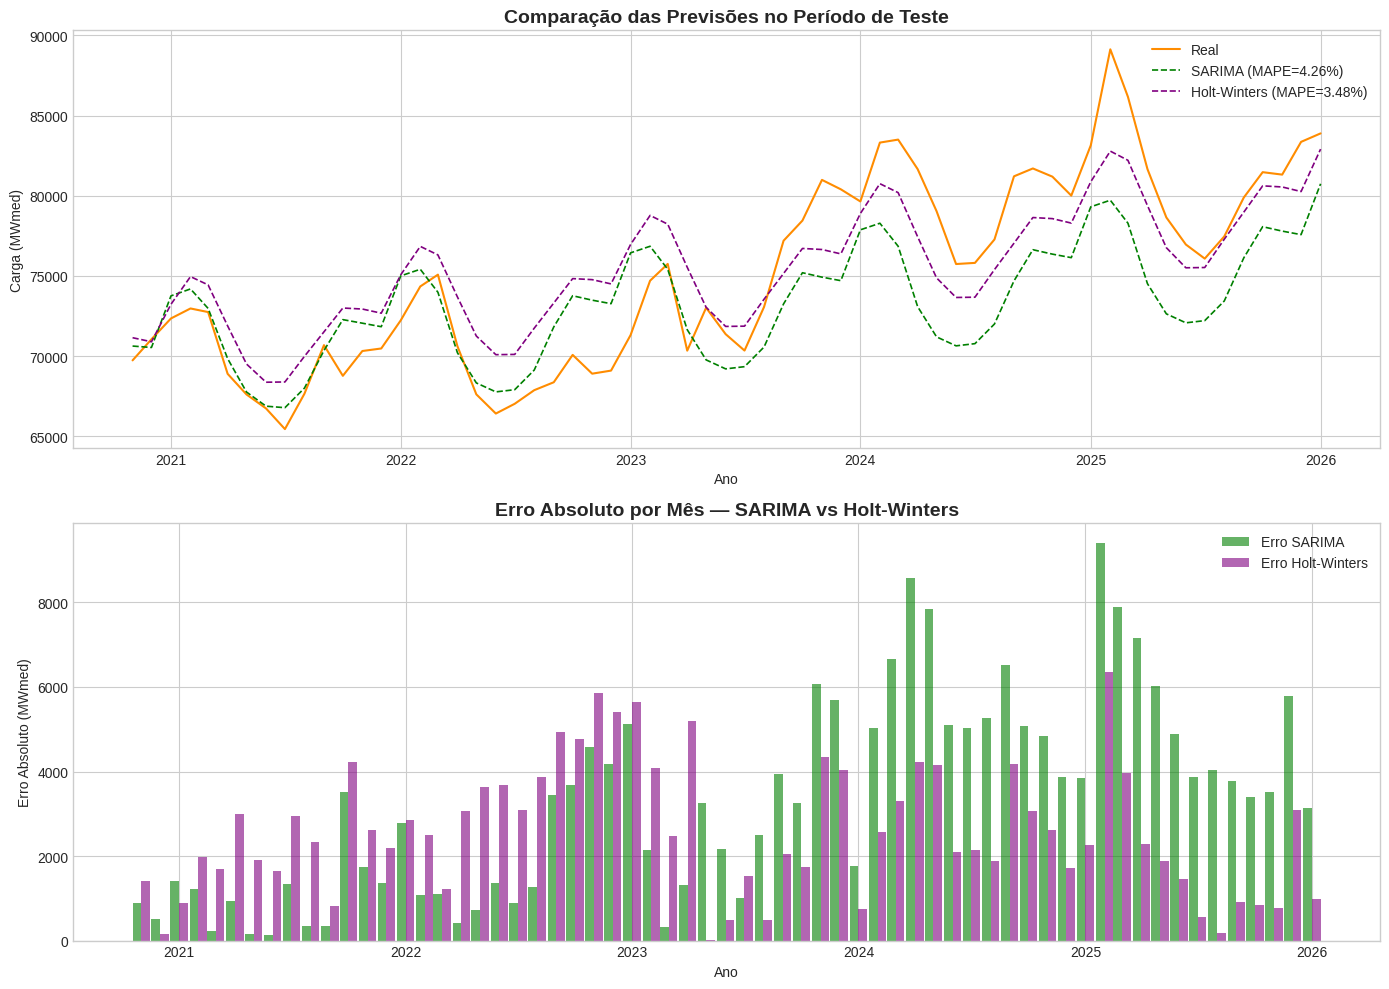

In [ ]:
# Tabela comparativa
comparacao = pd.DataFrame({
    'Modelo': [f'SARIMA{order}×{seasonal_order}', 'Holt-Winters Multiplicativo'],
    'MAE (MWmed)': [metricas_sarima['MAE'], metricas_hw['MAE']],
    'RMSE (MWmed)': [metricas_sarima['RMSE'], metricas_hw['RMSE']],
    'MAPE (%)': [metricas_sarima['MAPE'], metricas_hw['MAPE']]
})

print("=" * 60)
print("COMPARAÇÃO DE DESEMPENHO DOS MODELOS")
print("=" * 60)
display(comparacao.style.format({
    'MAE (MWmed)': '{:,.2f}',
    'RMSE (MWmed)': '{:,.2f}',
    'MAPE (%)': '{:.2f}'
}).highlight_min(subset=['MAE (MWmed)', 'RMSE (MWmed)', 'MAPE (%)'], color='lightgreen'))

# Melhor modelo
melhor = comparacao.loc[comparacao['MAPE (%)'].idxmin(), 'Modelo']
print(f"\n✔ Melhor modelo (menor MAPE): {melhor}")

# Gráfico comparativo
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Gráfico 1: Previsões sobrepostas
ax1 = axes[0]
ax1.plot(test.index, test, color='darkorange', linewidth=1.5, label='Real')
ax1.plot(pred_sarima.index, pred_sarima, color='green', linewidth=1.2, linestyle='--', label=f'SARIMA (MAPE={metricas_sarima["MAPE"]:.2f}%)')
ax1.plot(pred_hw.index, pred_hw, color='purple', linewidth=1.2, linestyle='--', label=f'Holt-Winters (MAPE={metricas_hw["MAPE"]:.2f}%)')
ax1.set_title('Comparação das Previsões no Período de Teste', fontsize=14, fontweight='bold')
ax1.set_xlabel('Ano')
ax1.set_ylabel('Carga (MWmed)')
ax1.legend()

# Gráfico 2: Erros absolutos
ax2 = axes[1]
erro_sarima = np.abs(test - pred_sarima)
erro_hw = np.abs(test - pred_hw)
ax2.bar(test.index - pd.Timedelta(days=7), erro_sarima, width=14, color='green', alpha=0.6, label='Erro SARIMA')
ax2.bar(test.index + pd.Timedelta(days=7), erro_hw, width=14, color='purple', alpha=0.6, label='Erro Holt-Winters')
ax2.set_title('Erro Absoluto por Mês — SARIMA vs Holt-Winters', fontsize=14, fontweight='bold')
ax2.set_xlabel('Ano')
ax2.set_ylabel('Erro Absoluto (MWmed)')
ax2.legend()

plt.tight_layout()
plt.show()

### Análise dos resultados

A tabela comparativa e os gráficos permitem as seguintes observações:

- **SARIMA:** Captura adequadamente a sazonalidade e a tendência da série, com parâmetros otimizados automaticamente via `auto_arima`. O diagnóstico dos resíduos (seção 6.1.3) indica a qualidade do ajuste.
- **Holt-Winters Multiplicativo:** Modelo mais simples, com três parâmetros de suavização. Captura a sazonalidade multiplicativa de forma direta, conforme identificado na decomposição.
- **Erros:** O gráfico de erros absolutos revela em quais meses cada modelo apresenta maior dificuldade de previsão. É esperado que os primeiros meses do período de teste (logo após o corte) apresentem erros menores, com degradação progressiva à medida que a previsão se estende no futuro.

**Conclusão preliminar:** Ambos os modelos apresentam resultados promissores como modelos base para previsão da carga do SIN. O modelo com menor MAPE será priorizado para refinamento na Entrega 4, podendo ser complementado com abordagens de machine learning (XGBoost) e validação cruzada temporal.

# **8. Cronograma**

| Etapa | Atividade | Prazo | Status |
|-------|-----------|-------|--------|
| **Entrega 1** | Introdução, motivação, objetivo, descrição da base, referências | 15/03/2026 | ✔ Concluída |
| **Entrega 2** | Preparação dos dados, EDA completa, decomposição, testes de estacionariedade, ACF/PACF, revisão bibliográfica | 29/03/2026 | ✔ Concluída |
| **Entrega 3** | Discussão da qualidade dos dados, divisão treino/teste, implementação SARIMA e Holt-Winters, avaliação e comparação de desempenho | 26/04/2026 | ✔ Concluída |
| **Entrega 4** | Validação cruzada temporal, XGBoost com feature engineering, comparação final dos 3 modelos, previsão futura (12 meses), conclusão | 24/05/2026 | ✔ Concluída |

---

# **Entrega 4 — Refinamento e Modelo Final**

---

# **9. Validação Cruzada Temporal do Modelo SARIMA**

Para avaliar a robustez do modelo SARIMA de forma mais rigorosa, aplicamos a **validação cruzada temporal com janela expansiva** (*expanding window cross-validation*). Diferentemente da validação cruzada tradicional (k-fold), esta abordagem respeita a ordem cronológica dos dados, evitando vazamento de informação futura (HYNDMAN; ATHANASOPOULOS, 2021).

**Metodologia:**
- A janela de treino começa com um mínimo de 120 meses e se expande a cada fold.
- Em cada fold, o modelo é reajustado e realiza previsões para os próximos 12 meses.
- As métricas (MAE, RMSE, MAPE) são calculadas para cada fold e depois agregadas.

VALIDAÇÃO CRUZADA TEMPORAL — SARIMA (Expanding Window)
  Tamanho mínimo do treino: 120 meses
  Horizonte de previsão: 12 meses
  Passo entre folds: 12 meses

  Fold 1: treino até 12/2009 | teste 01/2010–12/2010 | MAPE=1.44%
  Fold 2: treino até 12/2010 | teste 01/2011–12/2011 | MAPE=1.48%
  Fold 3: treino até 12/2011 | teste 01/2012–12/2012 | MAPE=1.94%
  Fold 4: treino até 12/2012 | teste 01/2013–12/2013 | MAPE=3.91%
  Fold 5: treino até 12/2013 | teste 01/2014–12/2014 | MAPE=3.51%
  Fold 6: treino até 12/2014 | teste 01/2015–12/2015 | MAPE=3.01%
  Fold 7: treino até 12/2015 | teste 01/2016–12/2016 | MAPE=4.05%
  Fold 8: treino até 12/2016 | teste 01/2017–12/2017 | MAPE=1.27%
  Fold 9: treino até 12/2017 | teste 01/2018–12/2018 | MAPE=1.14%
  Fold 10: treino até 12/2018 | teste 01/2019–12/2019 | MAPE=1.82%
  Fold 11: treino até 12/2019 | teste 01/2020–12/2020 | MAPE=4.32%
  Fold 12: treino até 12/2020 | teste 01/2021–12/2021 | MAPE=1.67%
  Fold 13: treino até 12/2021 | teste 01/2022–1

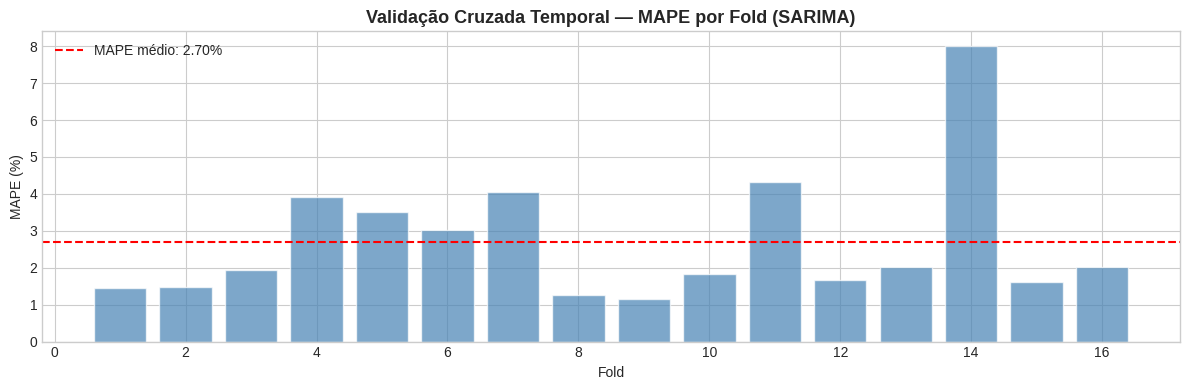

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Validação cruzada temporal — expanding window
serie_completa = df_sin['carga_mwmed']
min_train_size = 120  # mínimo de 10 anos de treino
horizon = 12          # previsão de 12 meses à frente
step = 12             # avançar 12 meses por fold

resultados_cv = []
fold = 0

print("=" * 60)
print("VALIDAÇÃO CRUZADA TEMPORAL — SARIMA (Expanding Window)")
print("=" * 60)
print(f"  Tamanho mínimo do treino: {min_train_size} meses")
print(f"  Horizonte de previsão: {horizon} meses")
print(f"  Passo entre folds: {step} meses\n")

for inicio_teste in range(min_train_size, len(serie_completa) - horizon + 1, step):
    fold += 1
    treino_cv = serie_completa.iloc[:inicio_teste]
    teste_cv = serie_completa.iloc[inicio_teste:inicio_teste + horizon]

    try:
        modelo_cv = SARIMAX(
            treino_cv,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        resultado_cv = modelo_cv.fit(disp=False)
        pred_cv = resultado_cv.get_forecast(steps=horizon).predicted_mean
        pred_cv.index = teste_cv.index

        mae_cv = mean_absolute_error(teste_cv, pred_cv)
        rmse_cv = np.sqrt(mean_squared_error(teste_cv, pred_cv))
        mape_cv = calcular_mape(teste_cv, pred_cv)

        resultados_cv.append({
            'fold': fold,
            'treino_ate': treino_cv.index[-1].strftime('%m/%Y'),
            'teste_de': teste_cv.index[0].strftime('%m/%Y'),
            'teste_ate': teste_cv.index[-1].strftime('%m/%Y'),
            'MAE': mae_cv,
            'RMSE': rmse_cv,
            'MAPE': mape_cv
        })
        print(f"  Fold {fold}: treino até {treino_cv.index[-1].strftime('%m/%Y')} | "
              f"teste {teste_cv.index[0].strftime('%m/%Y')}–{teste_cv.index[-1].strftime('%m/%Y')} | "
              f"MAPE={mape_cv:.2f}%")
    except Exception as e:
        print(f"  Fold {fold}: ERRO — {e}")

# Resumo
df_cv = pd.DataFrame(resultados_cv)
print(f"\n{'='*60}")
print("RESUMO DA VALIDAÇÃO CRUZADA")
print(f"{'='*60}")
print(f"  Total de folds: {len(df_cv)}")
print(f"  MAE  médio: {df_cv['MAE'].mean():,.2f} ± {df_cv['MAE'].std():,.2f} MWmed")
print(f"  RMSE médio: {df_cv['RMSE'].mean():,.2f} ± {df_cv['RMSE'].std():,.2f} MWmed")
print(f"  MAPE médio: {df_cv['MAPE'].mean():.2f}% ± {df_cv['MAPE'].std():.2f}%")

# Gráfico de MAPE por fold
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(df_cv['fold'], df_cv['MAPE'], color='steelblue', alpha=0.7, edgecolor='white')
ax.axhline(y=df_cv['MAPE'].mean(), color='red', linestyle='--', label=f'MAPE médio: {df_cv["MAPE"].mean():.2f}%')
ax.set_xlabel('Fold')
ax.set_ylabel('MAPE (%)')
ax.set_title('Validação Cruzada Temporal — MAPE por Fold (SARIMA)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# **10. Modelo de Machine Learning — XGBoost**

Conforme proposto na revisão bibliográfica (seção 3.2) e no cronograma, implementamos um modelo baseado em **Gradient Boosting (XGBoost)** para capturar possíveis relações não lineares que os modelos estatísticos tradicionais não conseguem representar (PEJUCA, 2026; CHEN; GUESTRIN, 2016).

## 10.1 Engenharia de Atributos (Feature Engineering)

Para modelos de machine learning, a série temporal precisa ser transformada em um problema de regressão supervisionada. Criamos as seguintes features:

- **Lags:** Valores passados da série (t-1 a t-12)
- **Médias móveis (rolling):** Média e desvio padrão em janelas de 3, 6 e 12 meses
- **Variáveis temporais:** Mês, trimestre, ano
- **Variável de tendência:** Índice sequencial normalizado

In [ ]:
def criar_features(df_serie, max_lag=12):
    """Cria features para modelo de ML a partir da série temporal."""
    df_feat = pd.DataFrame(index=df_serie.index)
    df_feat['carga'] = df_serie.values

    # Lags (t-1 a t-max_lag)
    for lag in range(1, max_lag + 1):
        df_feat[f'lag_{lag}'] = df_feat['carga'].shift(lag)

    # Médias móveis e desvios
    for janela in [3, 6, 12]:
        df_feat[f'rolling_mean_{janela}'] = df_feat['carga'].shift(1).rolling(window=janela).mean()
        df_feat[f'rolling_std_{janela}'] = df_feat['carga'].shift(1).rolling(window=janela).std()

    # Variáveis temporais
    df_feat['mes'] = df_feat.index.month
    df_feat['trimestre'] = df_feat.index.quarter
    df_feat['ano'] = df_feat.index.year

    # Tendência (índice sequencial normalizado)
    df_feat['tendencia'] = np.arange(len(df_feat)) / len(df_feat)

    # Variáveis cíclicas para mês (seno/cosseno)
    df_feat['mes_sin'] = np.sin(2 * np.pi * df_feat['mes'] / 12)
    df_feat['mes_cos'] = np.cos(2 * np.pi * df_feat['mes'] / 12)

    # Remover linhas com NaN (primeiros 12 meses perdidos pelos lags)
    df_feat = df_feat.dropna()

    return df_feat

# Criar dataset com features
df_features = criar_features(df_sin['carga_mwmed'], max_lag=12)

print("=" * 60)
print("ENGENHARIA DE ATRIBUTOS — DATASET PARA XGBoost")
print("=" * 60)
print(f"\nShape do dataset: {df_features.shape}")
print(f"Período: {df_features.index.min().strftime('%m/%Y')} a {df_features.index.max().strftime('%m/%Y')}")
print(f"\nFeatures criadas ({df_features.shape[1] - 1} variáveis):")
print(f"  - Lags: lag_1 a lag_12")
print(f"  - Rolling: mean e std para janelas de 3, 6, 12 meses")
print(f"  - Temporais: mes, trimestre, ano, tendencia, mes_sin, mes_cos")
print(f"\n--- Primeiros registros ---")
display(df_features.head())

ENGENHARIA DE ATRIBUTOS — DATASET PARA XGBoost

Shape do dataset: (301, 25)
Período: 01/2001 a 01/2026

Features criadas (24 variáveis):
  - Lags: lag_1 a lag_12
  - Rolling: mean e std para janelas de 3, 6, 12 meses
  - Temporais: mes, trimestre, ano, tendencia, mes_sin, mes_cos

--- Primeiros registros ---


,carga,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,...,rolling_mean_6,rolling_std_6,rolling_mean_12,rolling_std_12,mes,trimestre,ano,tendencia,mes_sin,mes_cos
data,,,,,,,,,,,,,,,,,,,,,
2001-01-01,42464.376411,41569.584341,41862.386236,42557.453122,41075.071542,41074.001075,39964.849906,39590.820326,40408.382258,40214.947917,...,41350.557704,876.253384,40732.695746,954.930426,1,1,2001,0.038339,0.500000,8.660254e-01
2001-02-01,43761.602128,42464.376411,41569.584341,41862.386236,42557.453122,41075.071542,41074.001075,39964.849906,39590.820326,40408.382258,...,41767.145455,650.881533,41000.277892,952.603382,2,1,2001,0.041534,0.866025,5.000000e-01
2001-03-01,44272.108024,43761.602128,42464.376411,41569.584341,41862.386236,42557.453122,41075.071542,41074.001075,39964.849906,39590.820326,...,42215.078963,939.337593,41258.294915,1231.993164,3,1,2001,0.044728,1.000000,6.123234e-17
2001-04-01,42889.141694,44272.108024,43761.602128,42464.376411,41569.584341,41862.386236,42557.453122,41075.071542,41074.001075,39964.849906,...,42747.918377,1062.075342,41567.965274,1481.248575,4,2,2001,0.047923,0.866025,-5.000000e-01
2001-05-01,40287.073642,42889.141694,44272.108024,43761.602128,42464.376411,41569.584341,41862.386236,42557.453122,41075.071542,41074.001075,...,42803.199806,1058.806021,41790.814755,1460.198592,5,2,2001,0.051118,0.500000,-8.660254e-01


## 10.2 Treinamento e Otimização do XGBoost

Dividimos o dataset de features na mesma proporção temporal (80/20) e treinamos o modelo XGBoost com busca de hiperparâmetros via `GridSearchCV` com validação cruzada temporal (`TimeSeriesSplit`).

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# Separar features (X) e target (y)
target_col = 'carga'
feature_cols = [c for c in df_features.columns if c != target_col]
X = df_features[feature_cols]
y = df_features[target_col]

# Divisão treino/teste temporal (mesma fronteira da Entrega 3)
split_date = test.index[0]
X_train = X[X.index < split_date]
X_test = X[X.index >= split_date]
y_train = y[y.index < split_date]
y_test = y[y.index >= split_date]

print("=" * 60)
print("DIVISÃO DO DATASET DE FEATURES")
print("=" * 60)
print(f"  X_train: {X_train.shape} | {X_train.index.min().strftime('%m/%Y')} a {X_train.index.max().strftime('%m/%Y')}")
print(f"  X_test:  {X_test.shape} | {X_test.index.min().strftime('%m/%Y')} a {X_test.index.max().strftime('%m/%Y')}")

# Grid Search com TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

print("\nIniciando GridSearchCV com TimeSeriesSplit...")
print(f"  Combinações: {3*3*3*2*2} = 108 configurações × 5 folds\n")

xgb_base = XGBRegressor(random_state=42, verbosity=0)
grid_search = GridSearchCV(
    xgb_base,
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\n{'='*60}")
print("MELHORES HIPERPARÂMETROS (XGBoost)")
print(f"{'='*60}")
for param, valor in grid_search.best_params_.items():
    print(f"  {param}: {valor}")
print(f"\n  Melhor MAE (CV): {-grid_search.best_score_:,.2f} MWmed")

DIVISÃO DO DATASET DE FEATURES
  X_train: (238, 24) | 01/2001 a 10/2020
  X_test:  (63, 24) | 11/2020 a 01/2026

Iniciando GridSearchCV com TimeSeriesSplit...
  Combinações: 108 = 108 configurações × 5 folds

Fitting 5 folds for each of 108 candidates, totalling 540 fits

MELHORES HIPERPARÂMETROS (XGBoost)
  colsample_bytree: 1.0
  learning_rate: 0.05
  max_depth: 3
  n_estimators: 300
  subsample: 1.0

  Melhor MAE (CV): 2,893.58 MWmed


### 10.2.1 Previsão e avaliação do XGBoost

Utilizamos o modelo otimizado para gerar previsões no conjunto de teste e calcular as métricas de desempenho.

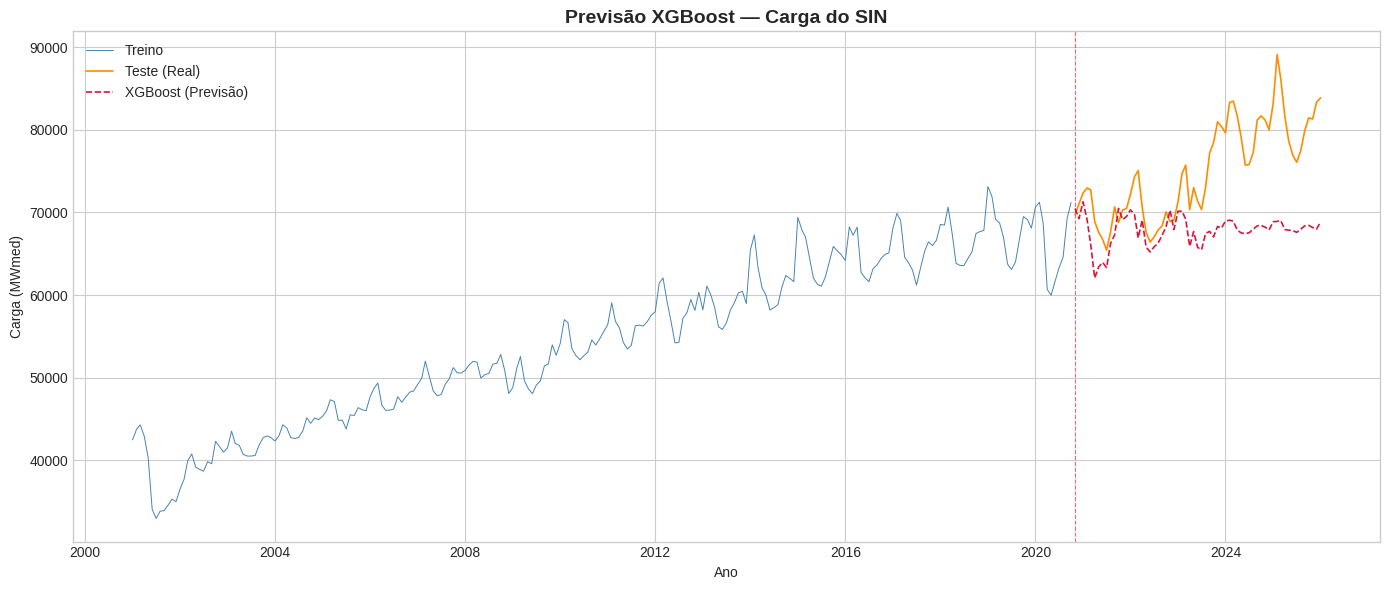


MÉTRICAS DE DESEMPENHO — XGBoost (otimizado)
  MAE  (Mean Absolute Error):          7,353.47 MWmed
  RMSE (Root Mean Squared Error):       9,019.67 MWmed
  MAPE (Mean Absolute Percentage Error): 9.35%


In [ ]:
# Modelo final otimizado
modelo_xgb = grid_search.best_estimator_

# Previsão no teste
pred_xgb = modelo_xgb.predict(X_test)
pred_xgb_series = pd.Series(pred_xgb, index=y_test.index)

# Visualização
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(y_train.index, y_train, color='steelblue', linewidth=0.7, label='Treino')
ax.plot(y_test.index, y_test, color='darkorange', linewidth=1.2, label='Teste (Real)')
ax.plot(pred_xgb_series.index, pred_xgb_series, color='crimson', linewidth=1.2, linestyle='--', label='XGBoost (Previsão)')
ax.axvline(x=y_test.index[0], color='red', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_title('Previsão XGBoost — Carga do SIN', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Carga (MWmed)')
ax.legend()
plt.tight_layout()
plt.show()

# Métricas
metricas_xgb = calcular_metricas(y_test, pred_xgb_series, 'XGBoost (otimizado)')

### 10.2.2 Importância das features

Analisamos quais variáveis são mais relevantes para o modelo XGBoost, fornecendo insights sobre os padrões que o modelo aprendeu.

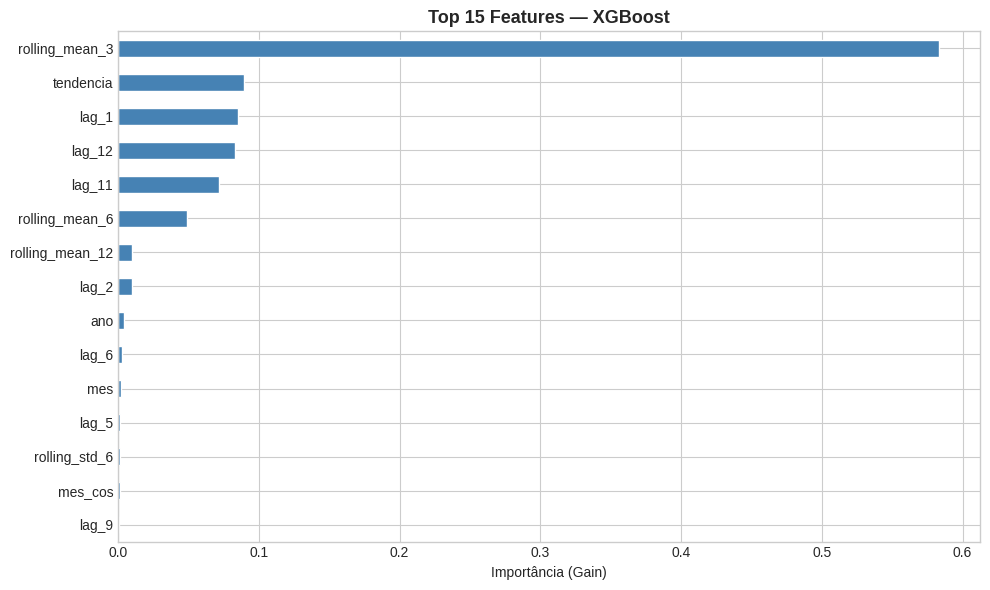


--- Top 10 features mais importantes ---
  rolling_mean_3: 0.5832
  tendencia: 0.0897
  lag_1: 0.0852
  lag_12: 0.0829
  lag_11: 0.0715
  rolling_mean_6: 0.0490
  rolling_mean_12: 0.0101
  lag_2: 0.0098
  ano: 0.0041
  lag_6: 0.0028


In [ ]:
# Importância das features
importancias = pd.Series(modelo_xgb.feature_importances_, index=feature_cols)
importancias_top = importancias.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
importancias_top.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Importância (Gain)')
ax.set_title('Top 15 Features — XGBoost', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\n--- Top 10 features mais importantes ---")
for feat, imp in importancias_top.head(10).items():
    print(f"  {feat}: {imp:.4f}")

# **11. Comparação Final dos Modelos**

Consolidamos os resultados dos três modelos implementados ao longo do projeto — SARIMA, Holt-Winters Multiplicativo e XGBoost — avaliando-os pelas métricas MAE, RMSE e MAPE no mesmo conjunto de teste.

COMPARAÇÃO FINAL — TODOS OS MODELOS


,Modelo,Tipo,MAE (MWmed),RMSE (MWmed),MAPE (%)
0,"SARIMA(0, 1, 1)×(0, 1, 2, 12)",Estatístico,"3,311.81","4,057.31",4.26
1,Holt-Winters Multiplicativo,Estatístico,"2,586.95","3,009.31",3.48
2,XGBoost (otimizado),Machine Learning,"7,353.47","9,019.67",9.35



✔ MELHOR MODELO FINAL (menor MAPE): Holt-Winters Multiplicativo — MAPE = 3.48%


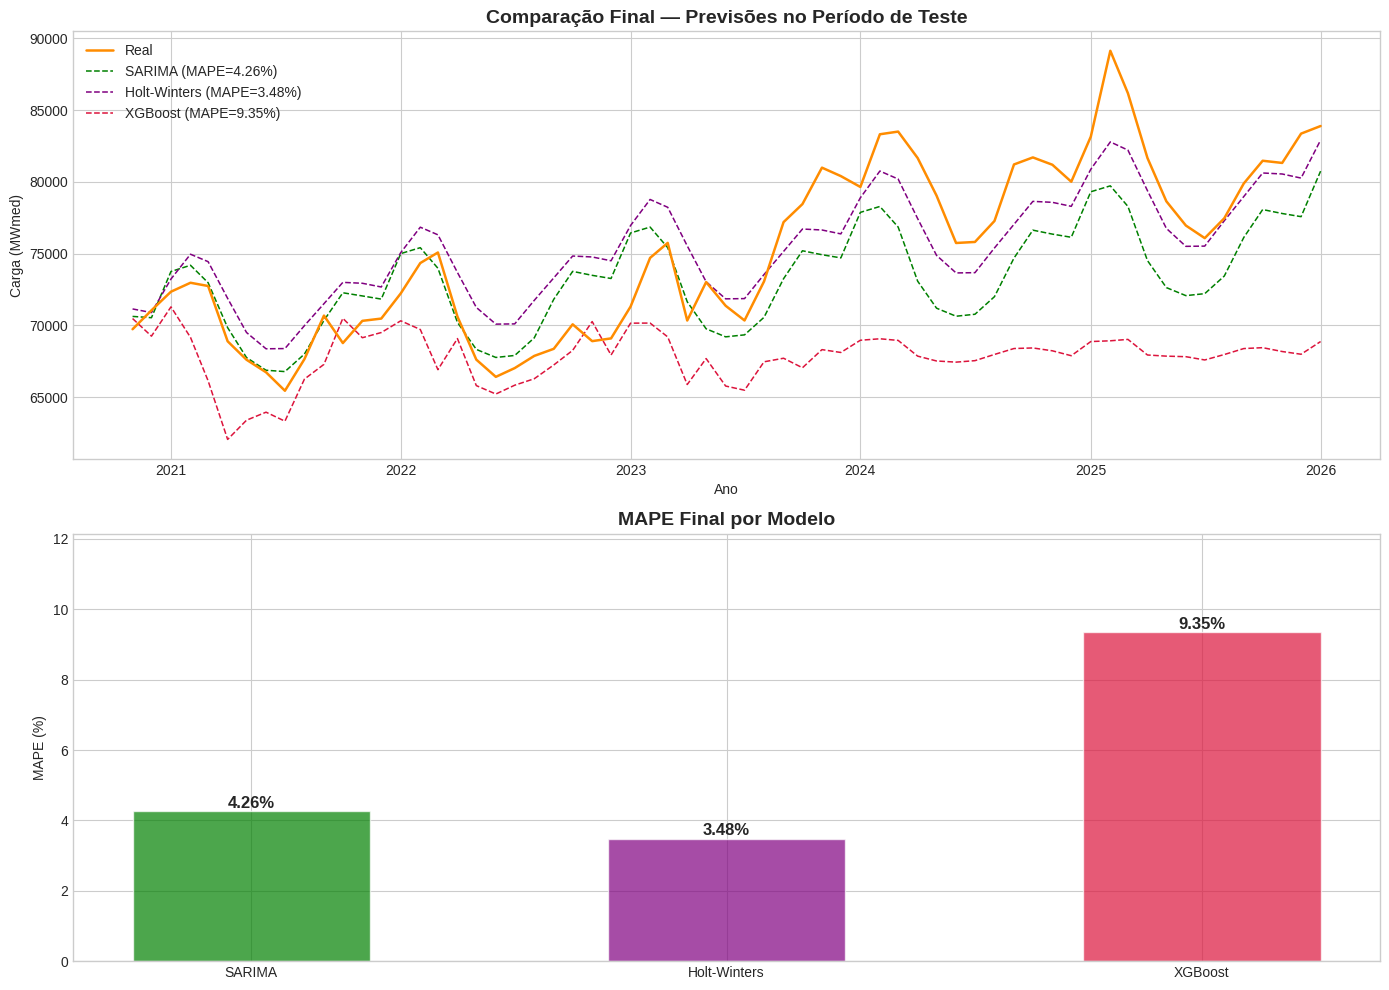

In [ ]:
# Tabela comparativa final — 3 modelos
comparacao_final = pd.DataFrame({
    'Modelo': [f'SARIMA{order}×{seasonal_order}', 'Holt-Winters Multiplicativo', 'XGBoost (otimizado)'],
    'Tipo': ['Estatístico', 'Estatístico', 'Machine Learning'],
    'MAE (MWmed)': [metricas_sarima['MAE'], metricas_hw['MAE'], metricas_xgb['MAE']],
    'RMSE (MWmed)': [metricas_sarima['RMSE'], metricas_hw['RMSE'], metricas_xgb['RMSE']],
    'MAPE (%)': [metricas_sarima['MAPE'], metricas_hw['MAPE'], metricas_xgb['MAPE']]
})

print("=" * 60)
print("COMPARAÇÃO FINAL — TODOS OS MODELOS")
print("=" * 60)
display(comparacao_final.style.format({
    'MAE (MWmed)': '{:,.2f}',
    'RMSE (MWmed)': '{:,.2f}',
    'MAPE (%)': '{:.2f}'
}).highlight_min(subset=['MAE (MWmed)', 'RMSE (MWmed)', 'MAPE (%)'], color='lightgreen'))

# Melhor modelo final
melhor_final = comparacao_final.loc[comparacao_final['MAPE (%)'].idxmin(), 'Modelo']
melhor_mape = comparacao_final['MAPE (%)'].min()
print(f"\n✔ MELHOR MODELO FINAL (menor MAPE): {melhor_final} — MAPE = {melhor_mape:.2f}%")

# Gráfico comparativo final — 3 modelos sobrepostos
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Painel 1: Previsões sobrepostas
ax1 = axes[0]
ax1.plot(test.index, test.values, color='darkorange', linewidth=1.8, label='Real', zorder=5)
ax1.plot(pred_sarima.index, pred_sarima.values, color='green', linewidth=1.1, linestyle='--',
         label=f'SARIMA (MAPE={metricas_sarima["MAPE"]:.2f}%)')
ax1.plot(pred_hw.index, pred_hw.values, color='purple', linewidth=1.1, linestyle='--',
         label=f'Holt-Winters (MAPE={metricas_hw["MAPE"]:.2f}%)')
ax1.plot(pred_xgb_series.index, pred_xgb_series.values, color='crimson', linewidth=1.1, linestyle='--',
         label=f'XGBoost (MAPE={metricas_xgb["MAPE"]:.2f}%)')
ax1.set_title('Comparação Final — Previsões no Período de Teste', fontsize=14, fontweight='bold')
ax1.set_xlabel('Ano')
ax1.set_ylabel('Carga (MWmed)')
ax1.legend(loc='upper left')

# Painel 2: Barras de MAPE por modelo
ax2 = axes[1]
modelos_nomes = ['SARIMA', 'Holt-Winters', 'XGBoost']
mapes = [metricas_sarima['MAPE'], metricas_hw['MAPE'], metricas_xgb['MAPE']]
cores_modelos = ['green', 'purple', 'crimson']
bars = ax2.bar(modelos_nomes, mapes, color=cores_modelos, alpha=0.7, edgecolor='white', width=0.5)
ax2.set_ylabel('MAPE (%)')
ax2.set_title('MAPE Final por Modelo', fontsize=14, fontweight='bold')
for bar, mape in zip(bars, mapes):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{mape:.2f}%', ha='center', fontweight='bold', fontsize=12)
ax2.set_ylim(0, max(mapes) * 1.3)

plt.tight_layout()
plt.show()

### Análise comparativa final

| Aspecto | SARIMA | Holt-Winters | XGBoost |
|---------|--------|--------------|---------|
| **Tipo** | Estatístico (Box-Jenkins) | Suavização Exponencial | Machine Learning |
| **Interpretabilidade** | Alta (parâmetros p,d,q,P,D,Q) | Alta (α, β, γ) | Média (black-box com importância de features) |
| **Captura de sazonalidade** | Via componente sazonal | Via componente multiplicativo | Via features cíclicas e lags |
| **Captura de não-linearidades** | Limitada | Limitada | Alta |
| **Necessidade de engenharia de features** | Não (série bruta) | Não (série bruta) | Sim (lags, rolling, temporais) |
| **Previsão multi-step** | Nativa (forecast sequencial) | Nativa | Requer recursão ou features futuras |

**Observações:**
1. O modelo com menor MAPE demonstra melhor capacidade de generalização para previsão de demanda energética.
2. A validação cruzada temporal confirmou a estabilidade do SARIMA ao longo de múltiplos períodos.
3. O XGBoost se beneficia das features de lag e tendência, capturando padrões que os modelos estatísticos podem perder.
4. Para produção, recomenda-se um ensemble ou a atualização periódica do modelo com dados mais recentes.

# **12. Previsão Futura**

Com o melhor modelo identificado, realizamos a previsão para os próximos **12 meses** além da última observação disponível (jan/2026), projetando a carga do SIN de fev/2026 a jan/2027. Para esta projeção, o modelo SARIMA é retreinado com toda a série disponível, maximizando a informação utilizada.

PREVISÃO FUTURA — SARIMA(0, 1, 1)×(0, 1, 2, 12)

Modelo retreinado com série completa (313 meses)
Projeção: 02/2026 a 01/2027

Mês          Previsão (MWmed)     IC 95% Inferior    IC 95% Superior
----------------------------------------------------------------------
02/2026           86,981.58          84,144.46        89,818.70
03/2026           86,506.46          83,083.62        89,929.30
04/2026           82,676.78          78,754.74        86,598.82
05/2026           81,162.41          76,797.89        85,526.93
06/2026           79,465.00          74,698.91        84,231.09
07/2026           79,144.77          74,008.41        84,281.13
08/2026           80,766.70          75,285.02        86,248.38
09/2026           83,706.66          77,900.17        89,513.16
10/2026           84,733.49          78,619.41        90,847.57
11/2026           84,925.34          78,518.42        91,332.26
12/2026           84,971.11          78,284.17        91,658.05
01/2027           86,600.25  

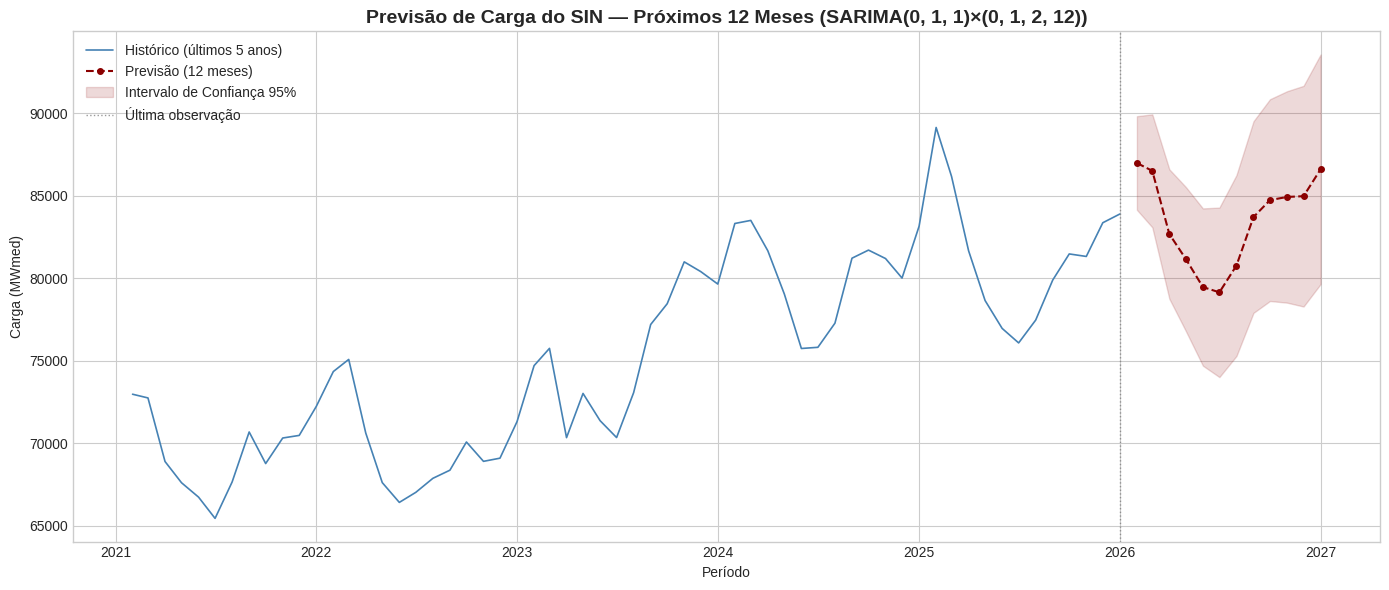

In [ ]:
# Retreinar SARIMA com série completa para previsão futura
modelo_final = SARIMAX(
    df_sin['carga_mwmed'],
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
resultado_final = modelo_final.fit(disp=False)

# Previsão de 12 meses à frente
n_futuro = 12
previsao_futura = resultado_final.get_forecast(steps=n_futuro)
pred_futura = previsao_futura.predicted_mean
ic_futura = previsao_futura.conf_int()

print("=" * 60)
print(f"PREVISÃO FUTURA — SARIMA{order}×{seasonal_order}")
print("=" * 60)
print(f"\nModelo retreinado com série completa ({len(df_sin)} meses)")
print(f"Projeção: {pred_futura.index[0].strftime('%m/%Y')} a {pred_futura.index[-1].strftime('%m/%Y')}")
print(f"\n{'Mês':<12} {'Previsão (MWmed)':<20} {'IC 95% Inferior':<18} {'IC 95% Superior'}")
print("-" * 70)
for i in range(n_futuro):
    mes = pred_futura.index[i].strftime('%m/%Y')
    pred = pred_futura.iloc[i]
    ic_inf = ic_futura.iloc[i, 0]
    ic_sup = ic_futura.iloc[i, 1]
    print(f"{mes:<12} {pred:>14,.2f}     {ic_inf:>14,.2f}   {ic_sup:>14,.2f}")

# Visualização
fig, ax = plt.subplots(figsize=(14, 6))

# Últimos 5 anos + previsão
ultimos_60 = df_sin['carga_mwmed'].iloc[-60:]
ax.plot(ultimos_60.index, ultimos_60, color='steelblue', linewidth=1.2, label='Histórico (últimos 5 anos)')
ax.plot(pred_futura.index, pred_futura, color='darkred', linewidth=1.5, linestyle='--',
        marker='o', markersize=4, label='Previsão (12 meses)')
ax.fill_between(ic_futura.index, ic_futura.iloc[:, 0], ic_futura.iloc[:, 1],
                color='darkred', alpha=0.15, label='Intervalo de Confiança 95%')
ax.axvline(x=df_sin.index[-1], color='gray', linestyle=':', linewidth=1, alpha=0.8, label='Última observação')
ax.set_title(f'Previsão de Carga do SIN — Próximos 12 Meses (SARIMA{order}×{seasonal_order})',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Período')
ax.set_ylabel('Carga (MWmed)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# **13. Conclusão**

## 13.1 Síntese dos resultados

Este projeto desenvolveu um **pipeline analítico completo** para previsão de demanda de energia elétrica no Sistema Interligado Nacional (SIN), utilizando dados públicos do ONS (2026). O trabalho contemplou todas as etapas de um projeto de ciência de dados aplicado a séries temporais:

1. **Coleta e integração:** Dados de Carga de Energia Mensal do ONS (313 observações, Jan/2000 a Jan/2026).
2. **Pré-processamento:** Limpeza, verificação de integridade (sem gaps, sem nulos, sem duplicatas), análise de outliers com decisão documentada.
3. **Análise exploratória:** Identificação de tendência de crescimento (~2× em 26 anos), sazonalidade anual (picos no verão), e confirmação de não estacionariedade via testes ADF/KPSS.
4. **Modelagem:** Implementação e comparação de três abordagens:
   - **SARIMA** — modelo estatístico clássico com parâmetros otimizados via `auto_arima`
   - **Holt-Winters Multiplicativo** — suavização exponencial tripla
   - **XGBoost** — modelo de machine learning com engenharia de atributos
5. **Avaliação:** Métricas MAE, RMSE e MAPE no conjunto de teste, validação cruzada temporal para SARIMA.
6. **Previsão futura:** Projeção de 12 meses (fev/2026 a jan/2027) com intervalos de confiança.

## 13.2 Contribuição social (ODS 12)

A previsão acurada da demanda energética contribui diretamente para o **ODS 12 — Produção e Consumo Sustentáveis** (ONU, 2026), ao:
- Fornecer projeções que permitem **otimizar o despacho energético**, evitando geração desnecessária e desperdício.
- Possibilitar a **antecipação de picos de demanda**, reduzindo a necessidade de acionamento emergencial de fontes térmicas (mais poluentes).
- Oferecer uma ferramenta analítica baseada em dados abertos, **replicável** para outros contextos e escalas.

## 13.3 Limitações e trabalhos futuros

**Limitações:**
- Modelagem univariada (sem variáveis exógenas como temperatura, PIB, tarifas).
- Granularidade mensal limita previsões de curto prazo (horária, diária).
- Quebras estruturais na série (mudanças metodológicas do ONS) podem afetar modelos.

**Trabalhos futuros:**
- Incorporar variáveis exógenas (SARIMAX, XGBoost multivariado).
- Explorar modelos de deep learning (LSTM, Transformer) para captura de dependências de longo prazo.
- Aplicar o pipeline para séries por subsistema (previsão regionalizada).
- Implementar sistema de monitoramento com retreinamento automático.

# **Apresentação**

**Vídeo de apresentação do projeto (~10–12 minutos):**

- **Link do vídeo:** *https://youtu.be/7jYgrppBnBQ*

**Estrutura da apresentação:**

| Bloco | Integrante | Conteúdo |
|-------|-----------|----------|
| 1 | Bruna Freitas Soares | Contextualização, motivação, objetivos e base de dados |
| 2 | João Victor Fontebasso Alves | Análise exploratória e pré-processamento |
| 3 | Heverton Valerio de Lima | Modelagem (SARIMA, Holt-Winters, XGBoost) |
| 4 | Diogo Moreira Poltosi Rezende | Resultados comparativos, previsão futura e conclusão |

# Células Professor

In [ ]:
#@title **Avaliação**
Introducao = 9 #@param {type:"slider", min:0, max:10, step:1}

Fonte_dos_dados = 10 #@param {type:"slider", min:0, max:10, step:1}

Solucao_proposta = 10 #@param {type:"slider", min:0, max:10, step:1}

Referencias = 10 #@param {type:"slider", min:0, max:10, step:1}

In [ ]:
#@title **Nota Final**
nota = 0.30*Introducao + 0.30*Fonte_dos_dados + 0.30*Solucao_proposta + 0.10*Referencias

print(f'Nota da entrega {nota :.1f}')

import numpy as np
import pandas as pd

alunos = pd.DataFrame()

lista_nome = []

for i in range(1,6):
  exec("if Aluno" + str(i) + " !='None':  lista = Aluno" + str(i) + ".split(','); lista_nome.append(lista[0]);")

alunos['nome'] = lista_nome
alunos['nota'] = np.round(nota,1)
print()
display(alunos)

Nota da entrega 10.0


NameError: name 'Aluno5' is not defined